# Branch Length Estimation Benchmark Analysis

Comparing IQ-TREE branch length estimation performance across:
- **VANILA**: CPU 1 core (baseline)
- **OMP_10**: CPU 10 threads
- **OMP_48**: CPU 48 threads
- **OPENACC**: GPU (Tesla V100)

Data types: AA (JTT, LG, Poisson, WAG) and DNA (GTR, HKY, JC, K2P)  
Tree types: rooted and unrooted  
100 taxa, 1M sites, 10 trees, 10 runs each

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

RESULTS_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse Log Files

In [2]:
def parse_log(filepath):
    """Extract metrics from an IQ-TREE log file."""
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    
    result = {}
    
    # Wall-clock time
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m:
        result['walltime'] = float(m.group(1))
    
    # CPU time
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m:
        result['cputime'] = float(m.group(1))
    
    # Log-likelihood
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m:
        result['log_likelihood'] = float(m.group(1))
    
    # Total tree length
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m:
        result['tree_length'] = float(m.group(1))
    
    # Parameters optimization time
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m:
        result['opt_time'] = float(m.group(1))
    
    # Kernel info
    m = re.search(r'Kernel:\s+(.+)', text)
    if m:
        result['kernel'] = m.group(1).strip()
    
    return result if 'walltime' in result else None


def classify_backend(filename):
    """Determine backend from filename."""
    if 'OPENACC' in filename:
        return 'OPENACC'
    elif 'VANILA' in filename:
        return 'VANILA'
    elif 'OMP_48' in filename:
        return 'OMP_48'
    elif 'OMP_10' in filename:
        return 'OMP_10'
    return 'UNKNOWN'


def extract_run_number(filename):
    """Extract the run number from filename."""
    # For OPENACC/VANILA: look for the LAST _runN_ pattern
    matches = re.findall(r'_run(\d+)_', filename)
    if matches:
        return int(matches[-1])
    return None


rows = []
for data_type in ['AA', 'DNA']:
    for tree_type in ['rooted', 'unrooted']:
        type_dir = RESULTS_DIR / data_type / tree_type
        if not type_dir.exists():
            continue
        for model_dir in sorted(type_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            model = model_dir.name
            for tree_dir in sorted(model_dir.iterdir()):
                if not tree_dir.is_dir():
                    continue
                tree = tree_dir.name
                for logfile in tree_dir.glob('*.log'):
                    fname = logfile.name
                    backend = classify_backend(fname)
                    run_num = extract_run_number(fname)
                    metrics = parse_log(logfile)
                    if metrics:
                        rows.append({
                            'data_type': data_type,
                            'tree_type': tree_type,
                            'model': model,
                            'tree': tree,
                            'backend': backend,
                            'run': run_num,
                            **metrics
                        })

df = pd.DataFrame(rows)
print(f'Parsed {len(df)} log entries')
print(f'Backends: {df.backend.unique()}')
print(f'Data types: {df.data_type.unique()}')
print(f'\nEntries per backend:')
print(df.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

Parsed 5007 log entries
Backends: ['OMP_10' 'OPENACC' 'VANILA' 'OMP_48']
Data types: ['AA' 'DNA']

Entries per backend:
backend    OMP_10  OMP_48  OPENACC  VANILA
data_type                                 
AA            800     800      633     156
DNA           800     800      480     538


In [3]:
# Save raw data
df.to_csv(SAVE_DIR / 'results_all.csv', index=False)
df.head()

,data_type,tree_type,model,tree,backend,run,walltime,cputime,log_likelihood,tree_length,opt_time,kernel
0,AA,rooted,JTT,tree_1,OMP_10,1,38.699,367.692,-9.546151e+07,21.479,37.463,AVX+FMA - 10 threads (10 CPU cores detected)
1,AA,rooted,JTT,tree_1,OPENACC,7,30.786,30.423,-9.546151e+07,21.479,27.919,GPU - 1 threads
2,AA,rooted,JTT,tree_1,OPENACC,9,31.316,30.921,-9.546151e+07,21.479,28.451,GPU - 1 threads
3,AA,rooted,JTT,tree_1,VANILA,4,292.749,285.890,-9.546151e+07,21.479,289.732,AVX+FMA - 1 threads (1 CPU cores detected)
4,AA,rooted,JTT,tree_1,OMP_48,3,17.529,643.733,-9.546151e+07,21.479,16.303,AVX+FMA - 48 threads (48 CPU cores detected)


## 2. Summary Statistics

In [4]:
# Summary stats per data_type, tree_type, model, backend
summary = df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    walltime_mean=('walltime', 'mean'),
    walltime_median=('walltime', 'median'),
    walltime_std=('walltime', 'std'),
    walltime_min=('walltime', 'min'),
    walltime_max=('walltime', 'max'),
    opt_time_mean=('opt_time', 'mean'),
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    tree_length_mean=('tree_length', 'mean'),
    n_runs=('walltime', 'count')
).round(3)

summary.to_csv(SAVE_DIR / 'results_summary.csv')
summary

walltime_mean  walltime_median  \
data_type tree_type model backend                                   
AA        rooted    JTT   OMP_10          35.724           38.441   
                          OMP_48          14.987           14.914   
                          OPENACC         27.632           25.260   
                          VANILA         256.579          253.979   
                    LG    OMP_10          37.423           39.136   
...                                          ...              ...   
DNA       unrooted  JC    VANILA          33.266           32.784   
                    K2P   OMP_10          20.579           18.652   
                          OMP_48           8.861            8.810   
                          OPENACC         38.616           38.068   
                          VANILA          75.284           74.440   

                                   walltime_std  walltime_min  walltime_max  \
data_type tree_type model backend                                             
AA        rooted    JTT   OMP_10          4.576        30.174        45.581   
                          OMP_48          2.630        11.465        20.910   
                          OPENACC         3.403        24.129        36.236   
                          VANILA         33.380       218.896       293.849   
                    LG    OMP_10          4.046        30.399        42.009   
...                                         ...           ...           ...   
DNA       unrooted  JC    VANILA          3.507        28.381        41.175   
                    K2P   OMP_10          9.257        11.314        76.693   
                          OMP_48          1.594         6.479        12.598   
                          OPENACC         1.939        36.527        43.577   
                          VANILA          2.839        71.509        83.199   

                                   opt_time_mean     logl_mean     logl_std  \
data_type tree_type model backend                                             
AA        rooted    JTT   OMP_10          34.420 -9.111275e+07  3380900.422   
                          OMP_48          13.559 -9.111275e+07  3380900.422   
                          OPENACC         24.655 -9.090144e+07  3731874.535   
                          VANILA         253.529 -9.321583e+07  2304014.334   
                    LG    OMP_10          36.144 -8.557224e+07  5047285.013   
...                                          ...           ...          ...   
DNA       unrooted  JC    VANILA          30.648 -6.822919e+07  2523722.796   
                    K2P   OMP_10          19.386 -6.721937e+07  3411879.996   
                          OMP_48           7.853 -6.721937e+07  3411879.996   
                          OPENACC         35.960 -6.734676e+07  4115337.826   
                          VANILA          72.702 -6.725675e+07  3971752.381   

                                   tree_length_mean  n_runs  
data_type tree_type model backend                            
AA        rooted    JTT   OMP_10             20.109     100  
                          OMP_48             20.109     100  
                          OPENACC            20.051      71  
                          VANILA             20.718      20  
                    LG    OMP_10             18.966     100  
...                                             ...     ...  
DNA       unrooted  JC    VANILA             20.094     100  
                    K2P   OMP_10             19.648     100  
                          OMP_48             19.648     100  
                          OPENACC            19.778      59  
                          VANILA             19.757      67  

[64 rows x 10 columns]

## 3. Verify Likelihood Consistency
Ensure all backends produce the same log-likelihood for each model/tree combination.

In [5]:
logl_check = df.groupby(['data_type', 'tree_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min())
).reset_index()

mismatches = logl_check[logl_check['logl_range'] > 0.01]
if len(mismatches) == 0:
    print('All backends produce identical log-likelihoods (within 0.01 tolerance).')
else:
    print(f'WARNING: {len(mismatches)} configurations with likelihood mismatches:')
    display(mismatches)

All backends produce identical log-likelihoods (within 0.01 tolerance).


## 4. Speedup Analysis

In [6]:
# Compute median walltime per configuration
median_wt = df.groupby(['data_type', 'tree_type', 'model', 'tree', 'backend'])['walltime'].median().reset_index()
median_wt.columns = ['data_type', 'tree_type', 'model', 'tree', 'backend', 'median_walltime']

# Pivot to get backends as columns
pivot = median_wt.pivot_table(index=['data_type', 'tree_type', 'model', 'tree'],
                               columns='backend', values='median_walltime').reset_index()

# Compute speedups relative to VANILA (1-core baseline)
for backend in ['OMP_10', 'OMP_48', 'OPENACC']:
    if backend in pivot.columns and 'VANILA' in pivot.columns:
        pivot[f'speedup_{backend}'] = pivot['VANILA'] / pivot[backend]

# Summary speedups by model
speedup_cols = [c for c in pivot.columns if c.startswith('speedup_')]
speedup_summary = pivot.groupby(['data_type', 'tree_type', 'model'])[speedup_cols].agg(['mean', 'median', 'min', 'max']).round(2)
speedup_summary.to_csv(SAVE_DIR / 'speedup_summary.csv')
speedup_summary

backend                     speedup_OMP_10                    speedup_OMP_48  \
                                      mean median   min   max           mean   
data_type tree_type model                                                      
AA        rooted    JTT               7.34   7.34  7.22  7.45          17.95   
                    LG                7.35   7.35  7.34  7.36          18.09   
                    Poisson           7.18   7.18  7.08  7.28          18.05   
                    WAG               6.98   6.98  6.94  7.03          18.32   
          unrooted  JTT               7.38   7.38  7.13  7.64          18.09   
                    LG                7.39   7.39  7.38  7.41          18.95   
                    Poisson           7.43   7.43  7.43  7.43          17.91   
                    WAG               7.42   7.42  7.38  7.47          18.90   
DNA       rooted    GTR               2.99   3.08  2.81  3.08           8.73   
                    HKY               3.44   3.03  2.61  4.52           8.16   
                    JC                3.28   3.27  2.77  4.22           7.57   
                    K2P               3.42   3.08  2.90  4.01           8.58   
          unrooted  GTR               4.30   4.55  3.50  4.62           8.84   
                    HKY               4.07   4.51  3.21  4.91           8.17   
                    JC                4.42   4.14  3.45  5.54           7.41   
                    K2P               4.08   4.23  3.15  4.73           9.22   

backend                                          speedup_OPENACC               \
                            median    min    max            mean median   min   
data_type tree_type model                                                       
AA        rooted    JTT      17.95  17.07  18.82            9.18   9.18  9.08   
                    LG       18.09  17.93  18.25            9.10   9.10  9.09   
                    Poisson  18.05  17.89  18.22            9.15   9.15  9.07   
                    WAG      18.32  18.21  18.43            9.01   9.01  8.88   
          unrooted  JTT      18.09  17.78  18.39            8.97   8.97  8.89   
                    LG       18.95  18.94  18.95            9.18   9.18  9.17   
                    Poisson  17.91  17.78  18.04            9.09   9.09  9.09   
                    WAG      18.90  18.65  19.15            9.38   9.38  9.38   
DNA       rooted    GTR       8.84   7.07  10.29            2.62   2.64  2.32   
                    HKY       7.93   6.36   9.86            1.81   1.78  1.71   
                    JC        7.39   6.57   8.78            1.17   1.16  1.14   
                    K2P       9.37   6.48  10.11            1.79   1.78  1.71   
          unrooted  GTR       8.87   8.04   9.59            2.63   2.64  2.46   
                    HKY       7.93   7.16   9.53            1.90   1.89  1.80   
                    JC        7.22   6.53   8.46            1.18   1.18  1.16   
                    K2P       9.36   7.62  10.51            1.95   1.95  1.85   

backend                            
                              max  
data_type tree_type model          
AA        rooted    JTT      9.27  
                    LG       9.11  
                    Poisson  9.22  
                    WAG      9.13  
          unrooted  JTT      9.05  
                    LG       9.20  
                    Poisson  9.09  
                    WAG      9.38  
DNA       rooted    GTR      2.91  
                    HKY      1.93  
                    JC       1.19  
                    K2P      1.87  
          unrooted  GTR      2.79  
                    HKY      2.04  
                    JC       1.19  
                    K2P      2.08

## 5. Wall-clock Time Comparison Plots

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

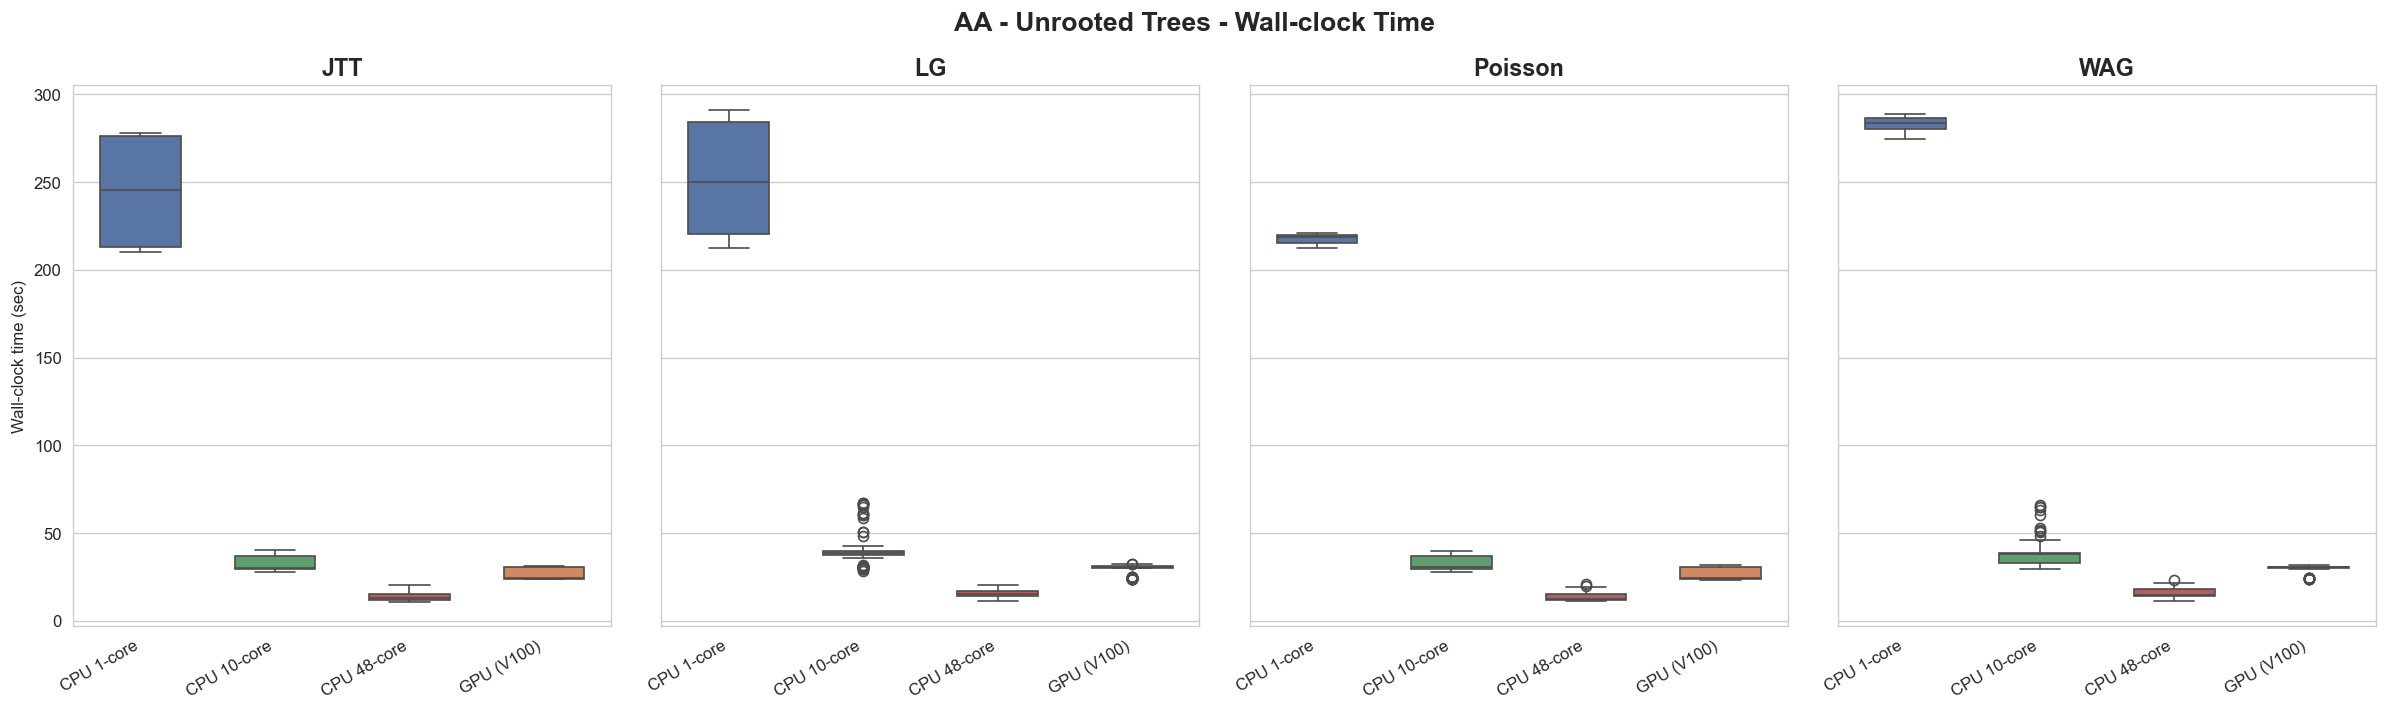

Saved: walltime_AA_unrooted.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

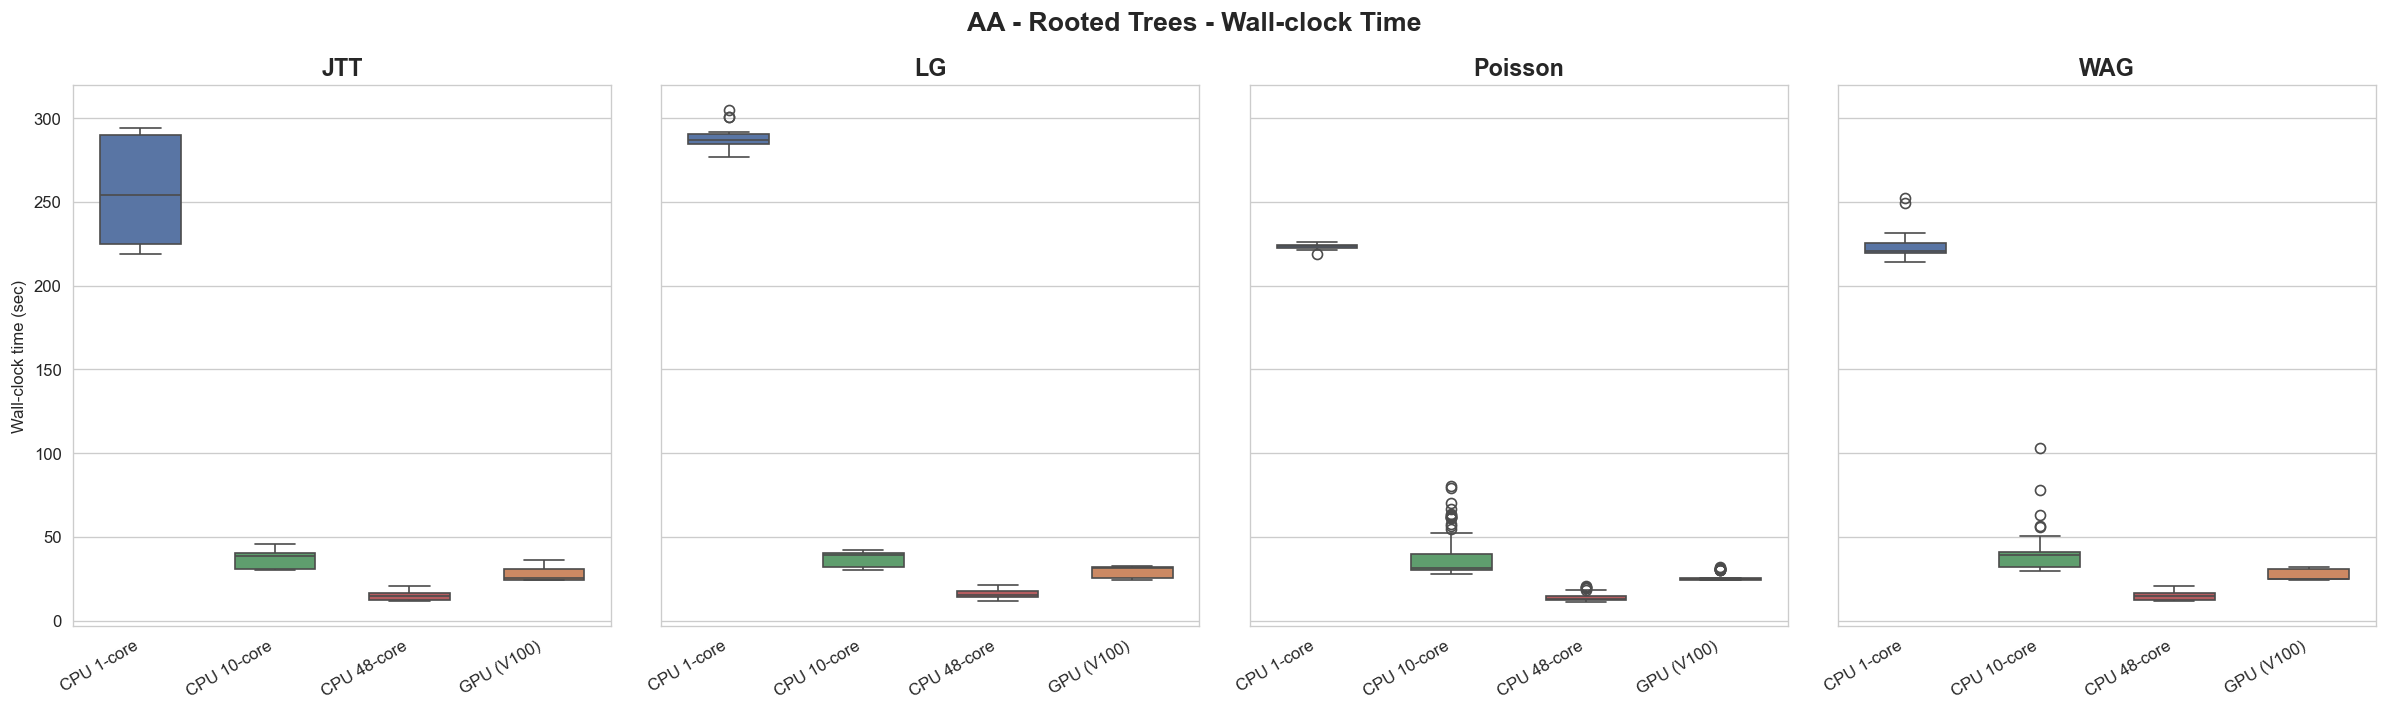

Saved: walltime_AA_rooted.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

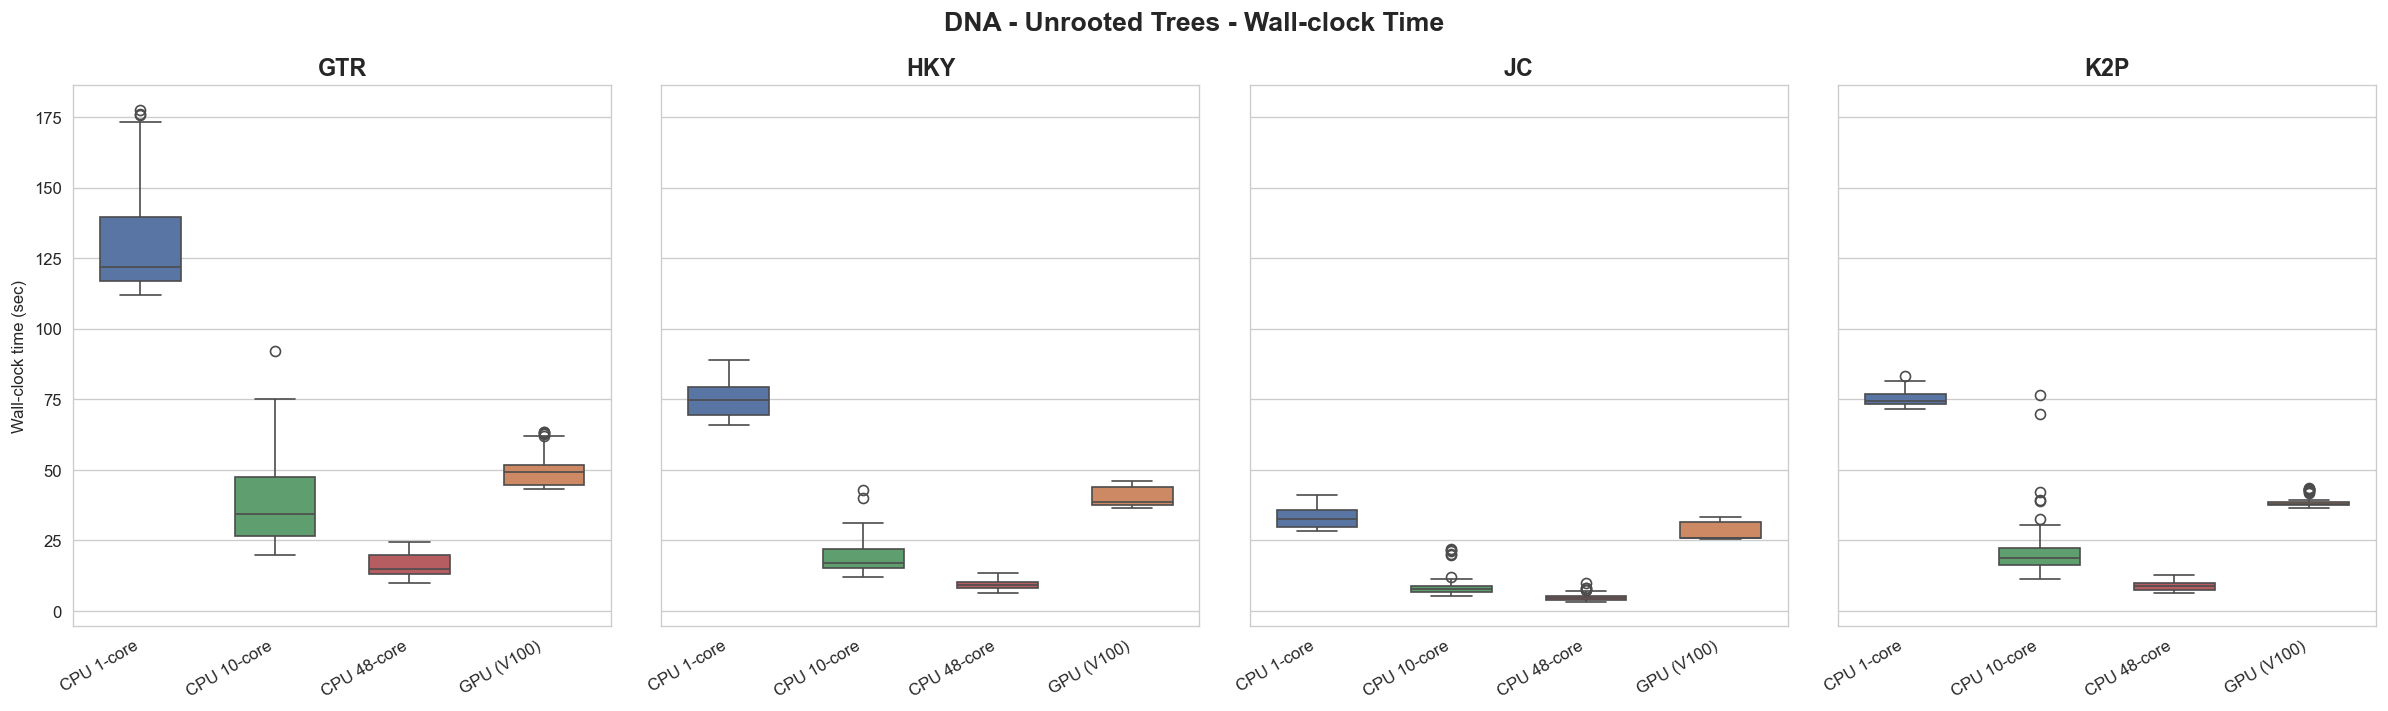

Saved: walltime_DNA_unrooted.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/3496460792.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

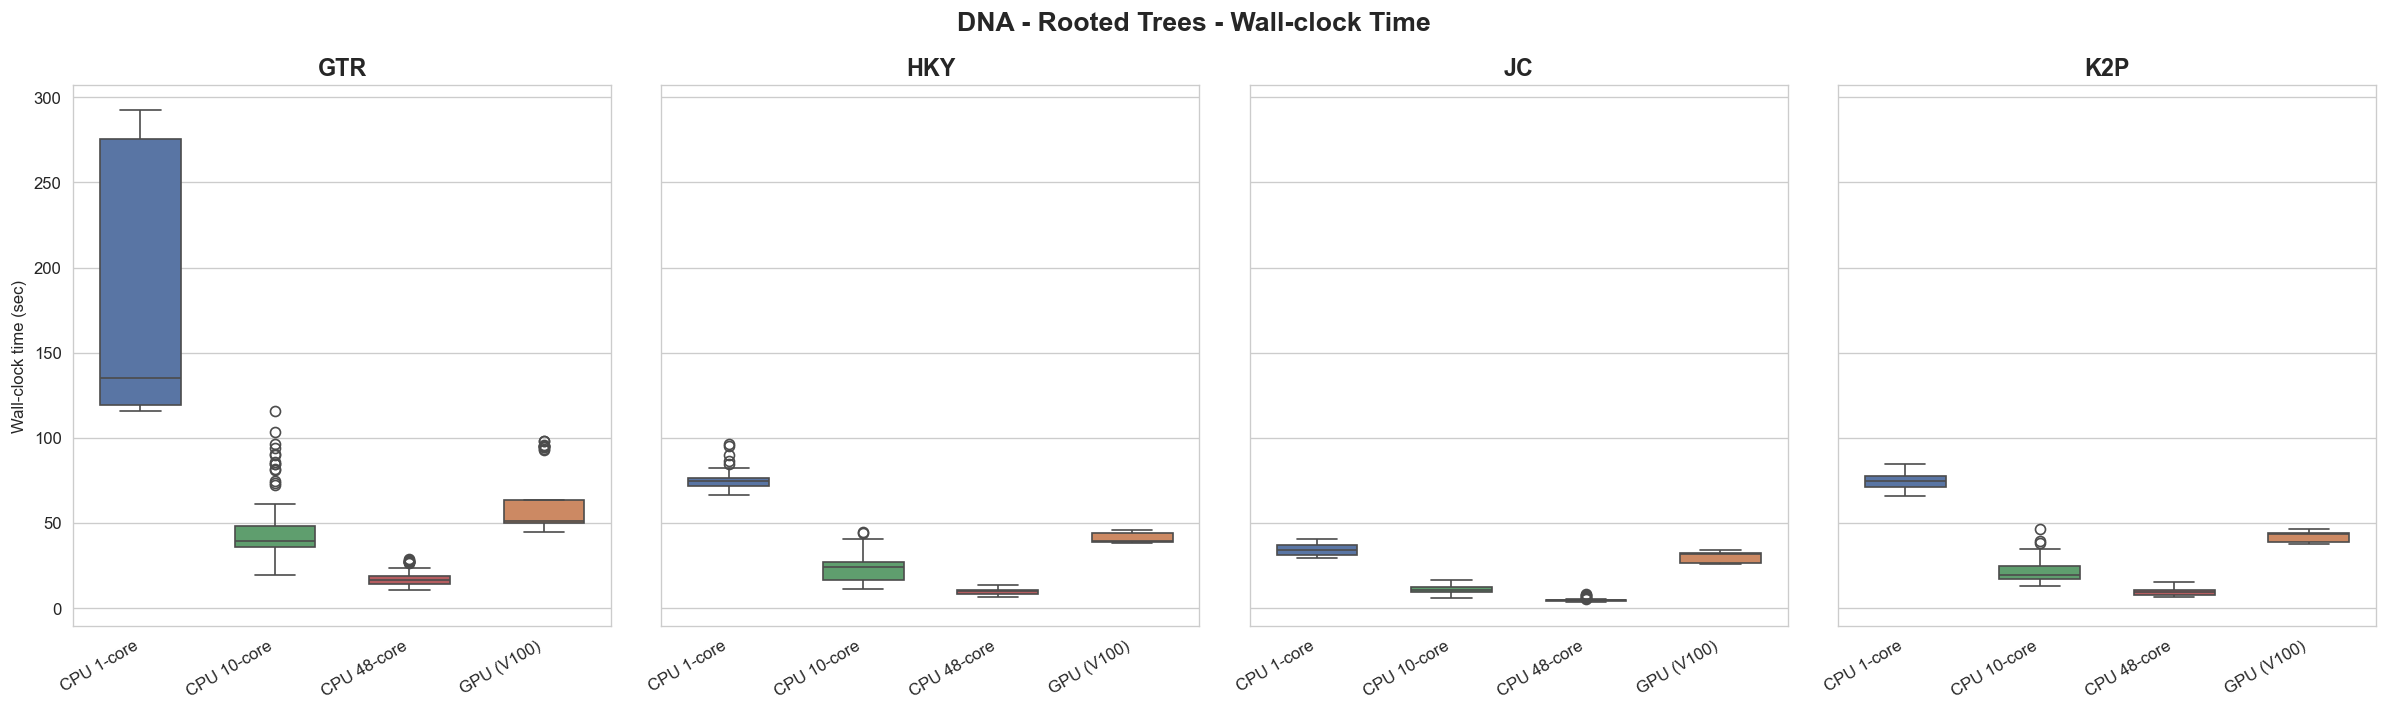

Saved: walltime_DNA_rooted.png


In [7]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
backend_colors = {'VANILA': '#4C72B0', 'OMP_10': '#55A868', 'OMP_48': '#C44E52', 'OPENACC': '#DD8452'}
backend_labels = {'VANILA': 'CPU 1-core', 'OMP_10': 'CPU 10-core', 'OMP_48': 'CPU 48-core', 'OPENACC': 'GPU (V100)'}

for data_type in ['AA', 'DNA']:
    for tree_type in ['unrooted', 'rooted']:
        subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)]
        if subset.empty:
            continue
        
        models = sorted(subset['model'].unique())
        fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 6), sharey=True)
        if len(models) == 1:
            axes = [axes]
        
        for ax, model in zip(axes, models):
            model_data = subset[subset['model'] == model]
            present_backends = [b for b in backend_order if b in model_data['backend'].unique()]
            palette = [backend_colors[b] for b in present_backends]
            
            sns.boxplot(data=model_data, x='backend', y='walltime',
                       order=present_backends, palette=palette, ax=ax, width=0.6)
            ax.set_title(model, fontsize=14, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel('Wall-clock time (sec)' if ax == axes[0] else '')
            ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
        
        fig.suptitle(f'{data_type} - {tree_type.capitalize()} Trees - Wall-clock Time', fontsize=16, fontweight='bold')
        plt.tight_layout()
        fname = f'walltime_{data_type}_{tree_type}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## 6. Speedup Bar Charts

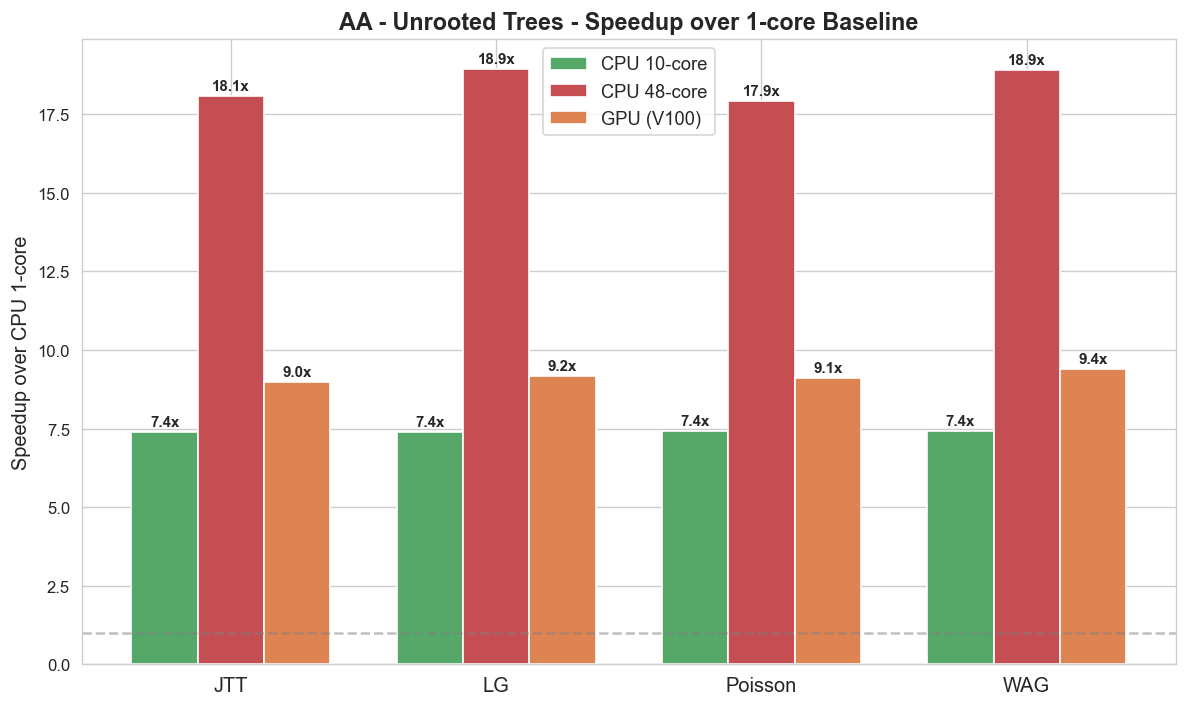

Saved: speedup_AA_unrooted.png


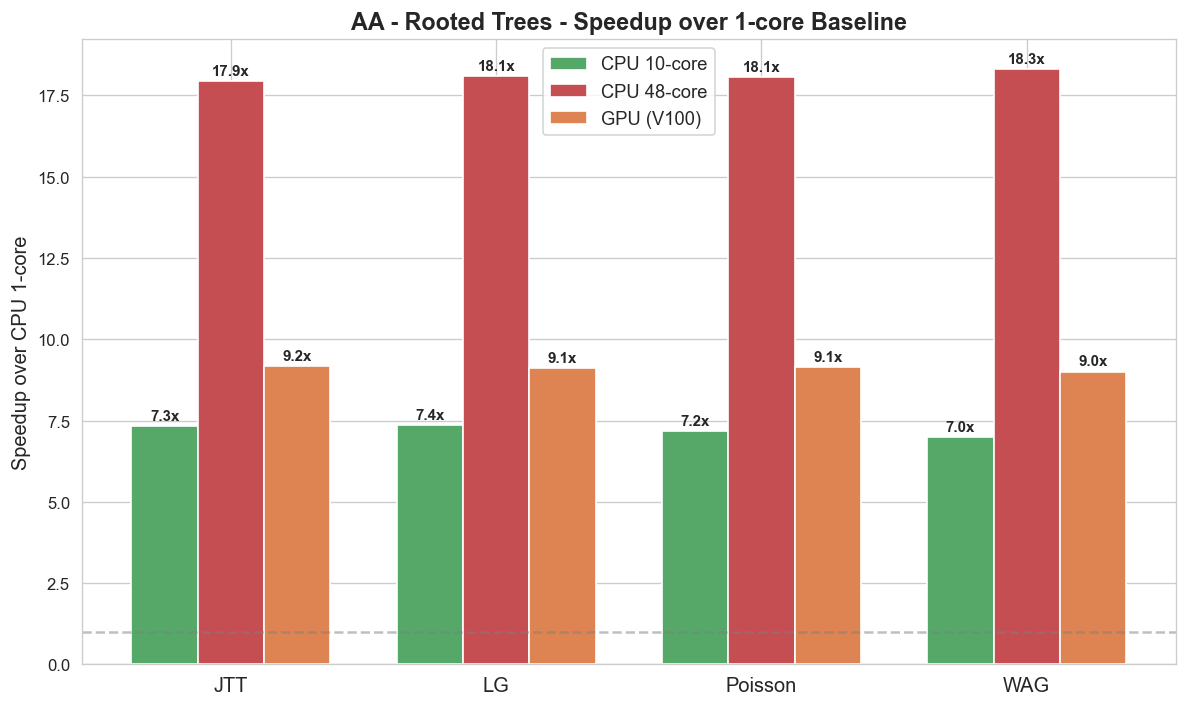

Saved: speedup_AA_rooted.png


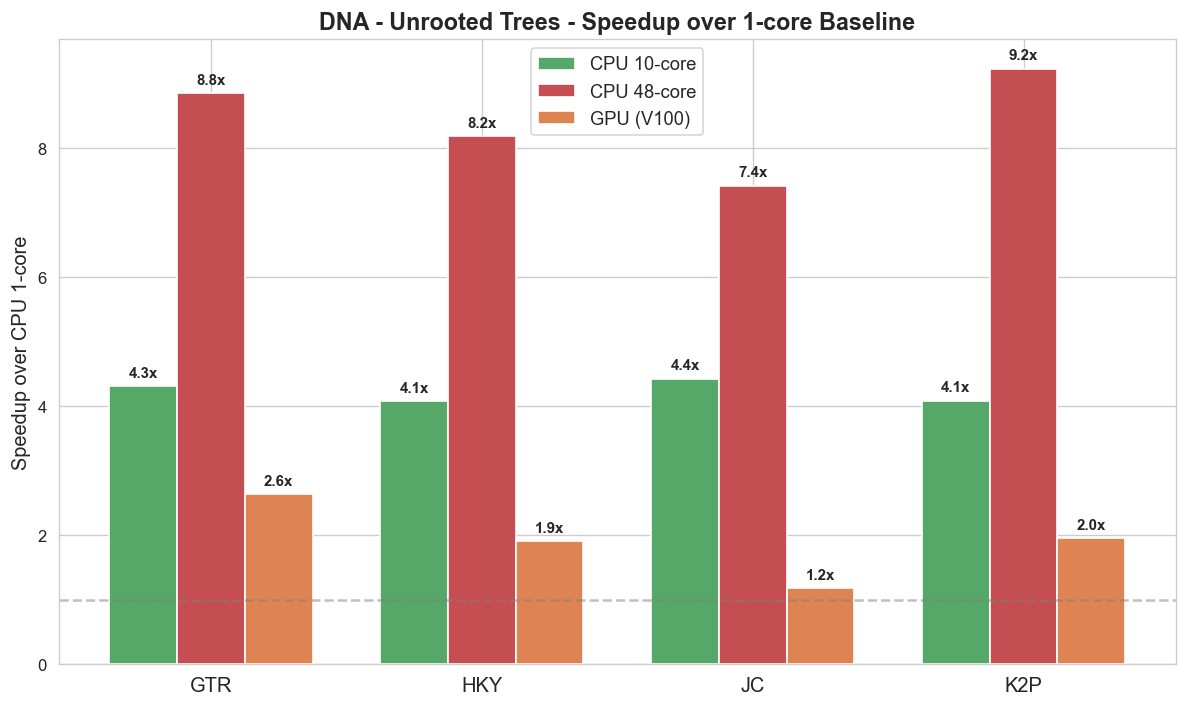

Saved: speedup_DNA_unrooted.png


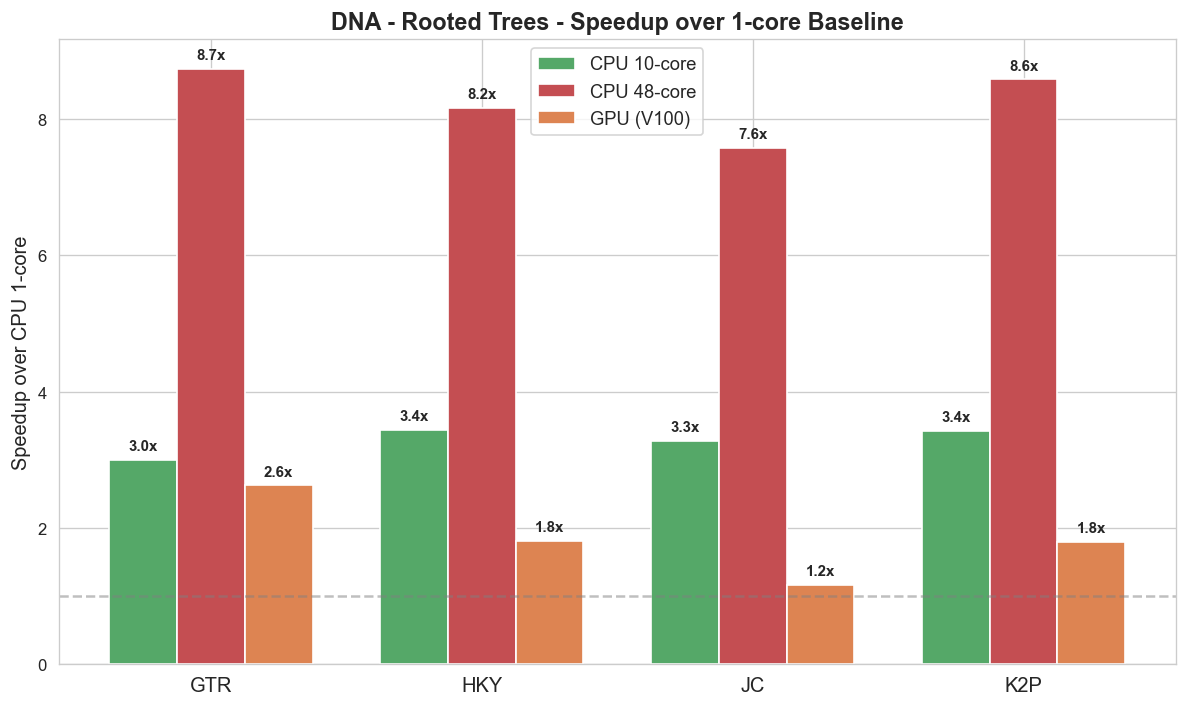

Saved: speedup_DNA_rooted.png


In [8]:
speedup_colors = {'speedup_OMP_10': '#55A868', 'speedup_OMP_48': '#C44E52', 'speedup_OPENACC': '#DD8452'}
speedup_labels = {'speedup_OMP_10': 'CPU 10-core', 'speedup_OMP_48': 'CPU 48-core', 'speedup_OPENACC': 'GPU (V100)'}

for data_type in ['AA', 'DNA']:
    for tree_type in ['unrooted', 'rooted']:
        sub = pivot[(pivot['data_type'] == data_type) & (pivot['tree_type'] == tree_type)]
        if sub.empty:
            continue
        
        # Mean speedup per model
        present_speedups = [c for c in speedup_cols if c in sub.columns and sub[c].notna().any()]
        if not present_speedups:
            continue
        
        mean_speedup = sub.groupby('model')[present_speedups].mean()
        
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(mean_speedup))
        width = 0.25
        
        for i, col in enumerate(present_speedups):
            bars = ax.bar(x + i * width, mean_speedup[col], width,
                         label=speedup_labels.get(col, col), color=speedup_colors.get(col, 'gray'))
            for bar, val in zip(bars, mean_speedup[col]):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                       f'{val:.1f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_xticks(x + width * (len(present_speedups) - 1) / 2)
        ax.set_xticklabels(mean_speedup.index, fontsize=12)
        ax.set_ylabel('Speedup over CPU 1-core', fontsize=12)
        ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
        ax.legend(fontsize=11)
        ax.set_title(f'{data_type} - {tree_type.capitalize()} Trees - Speedup over 1-core Baseline',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        fname = f'speedup_{data_type}_{tree_type}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## 7. Per-Tree Runtime Variation

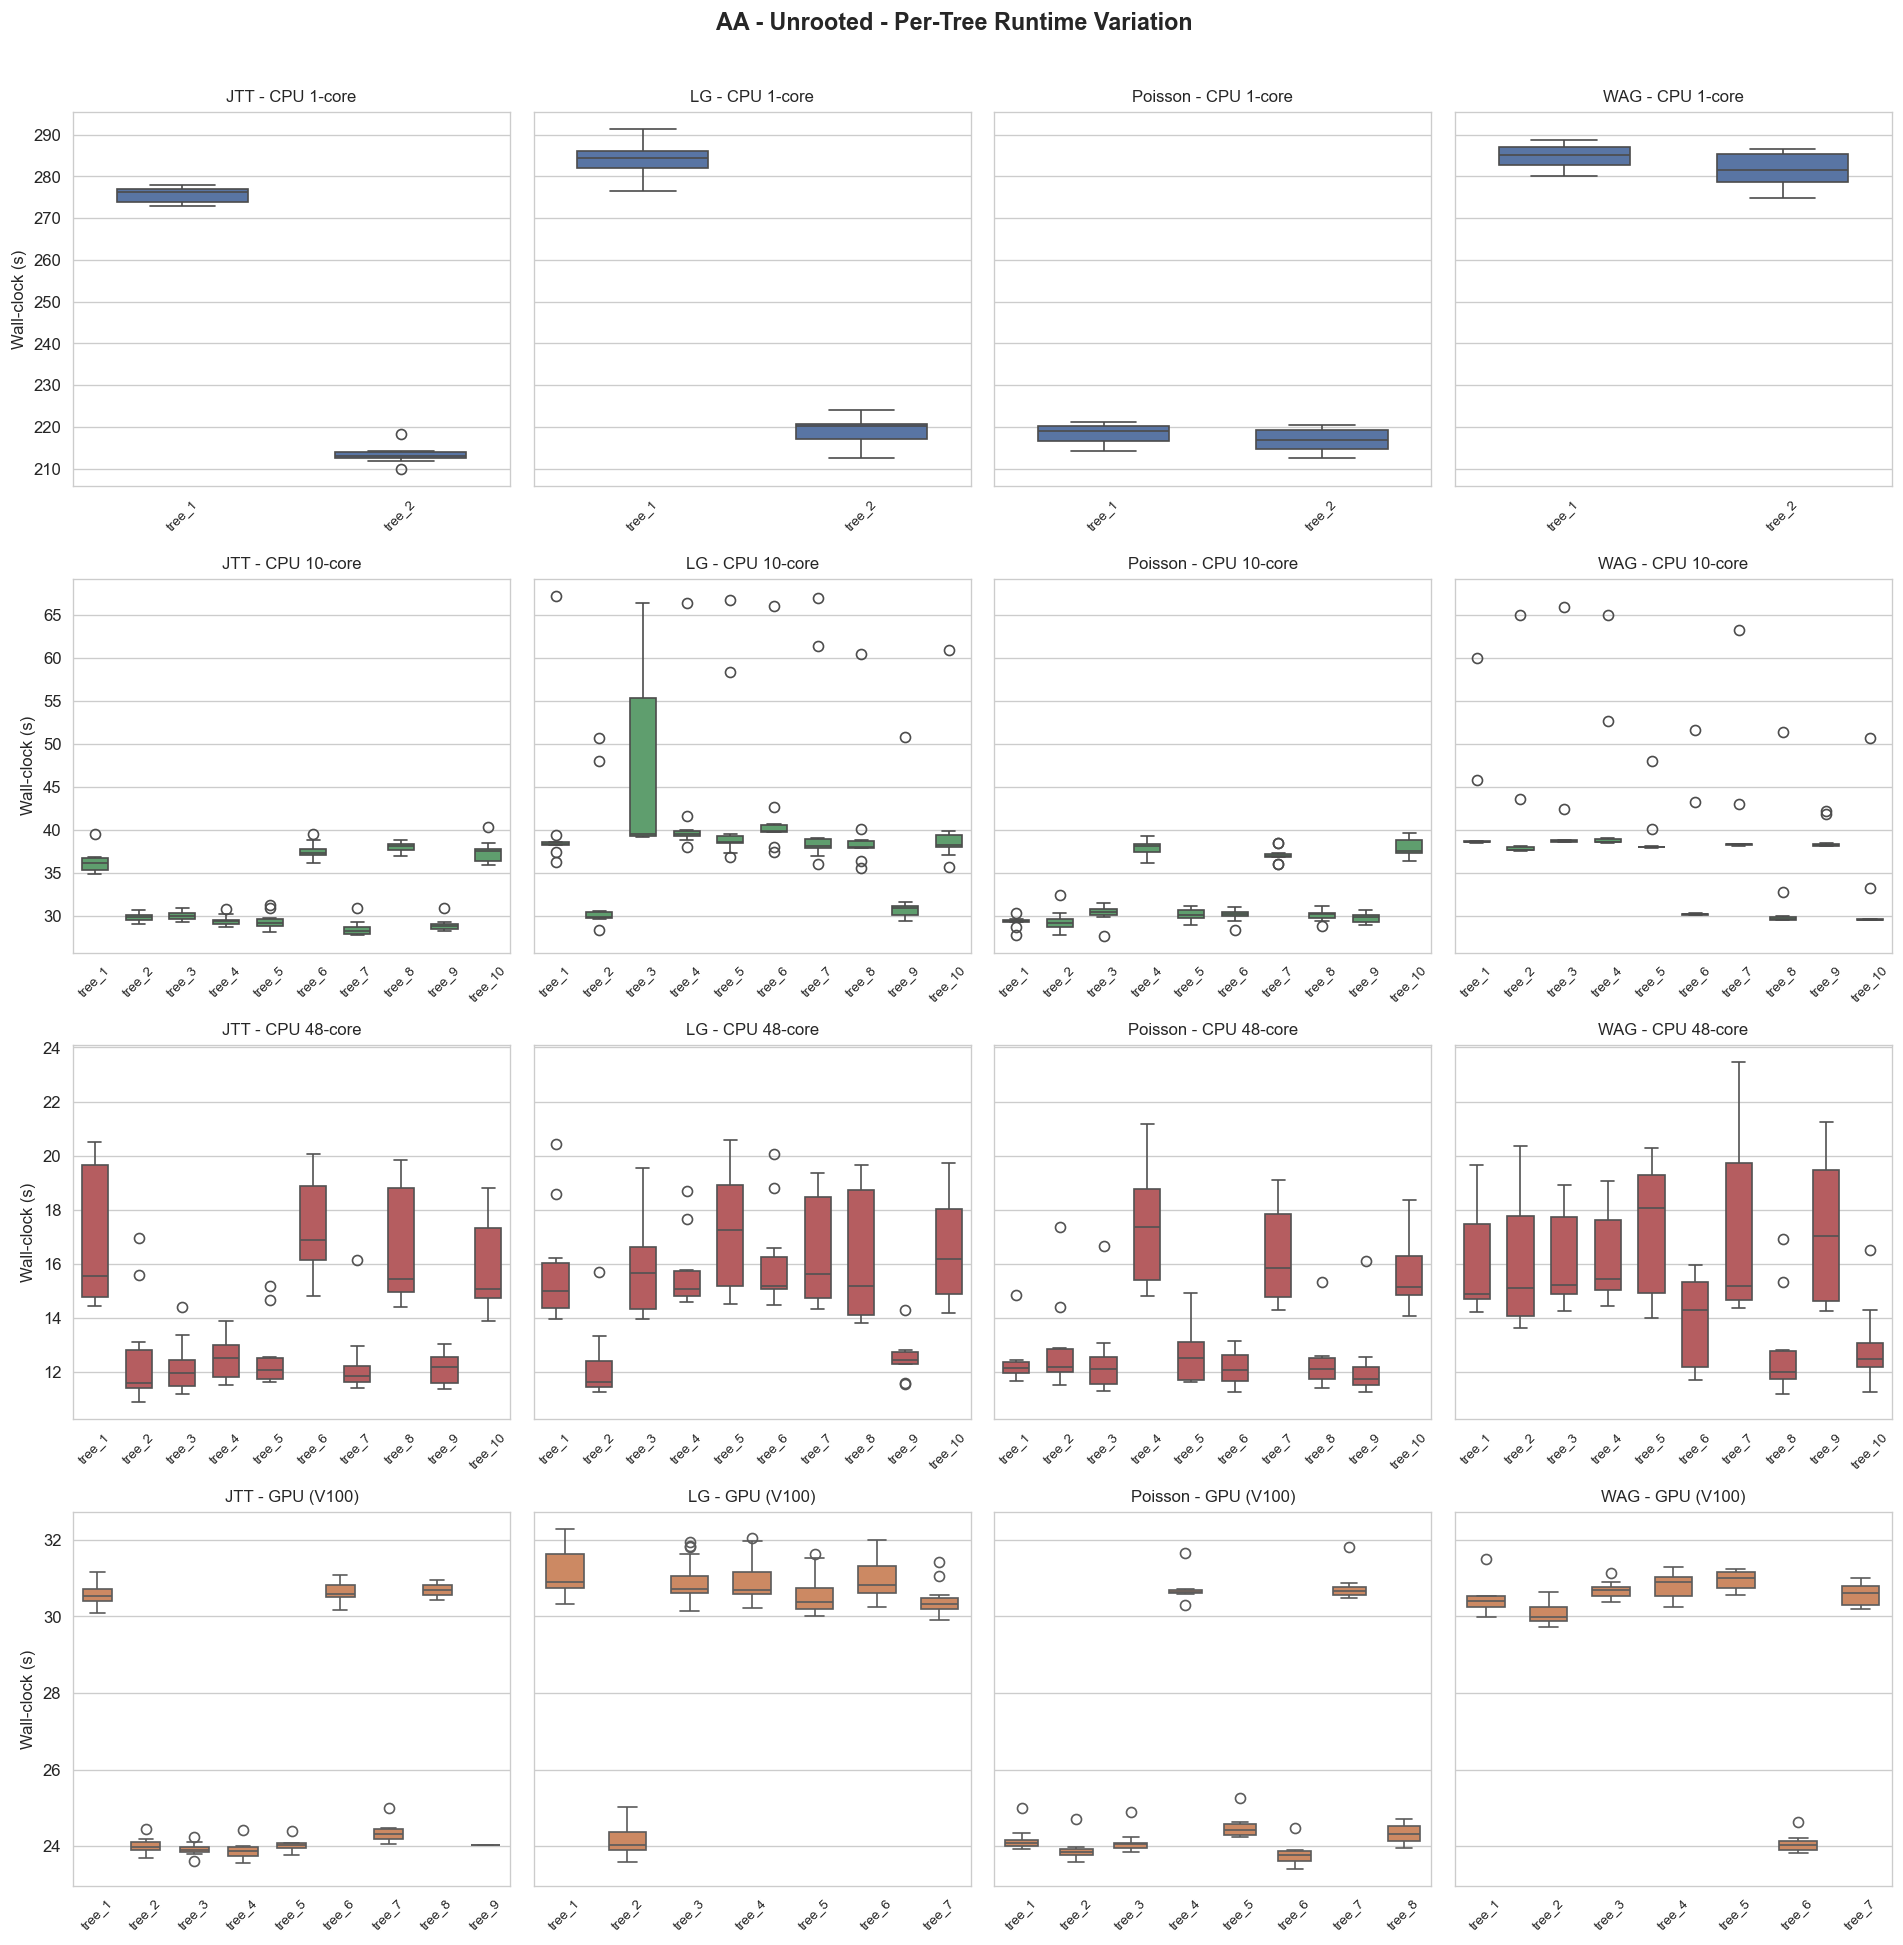

Saved: per_tree_AA_unrooted.png


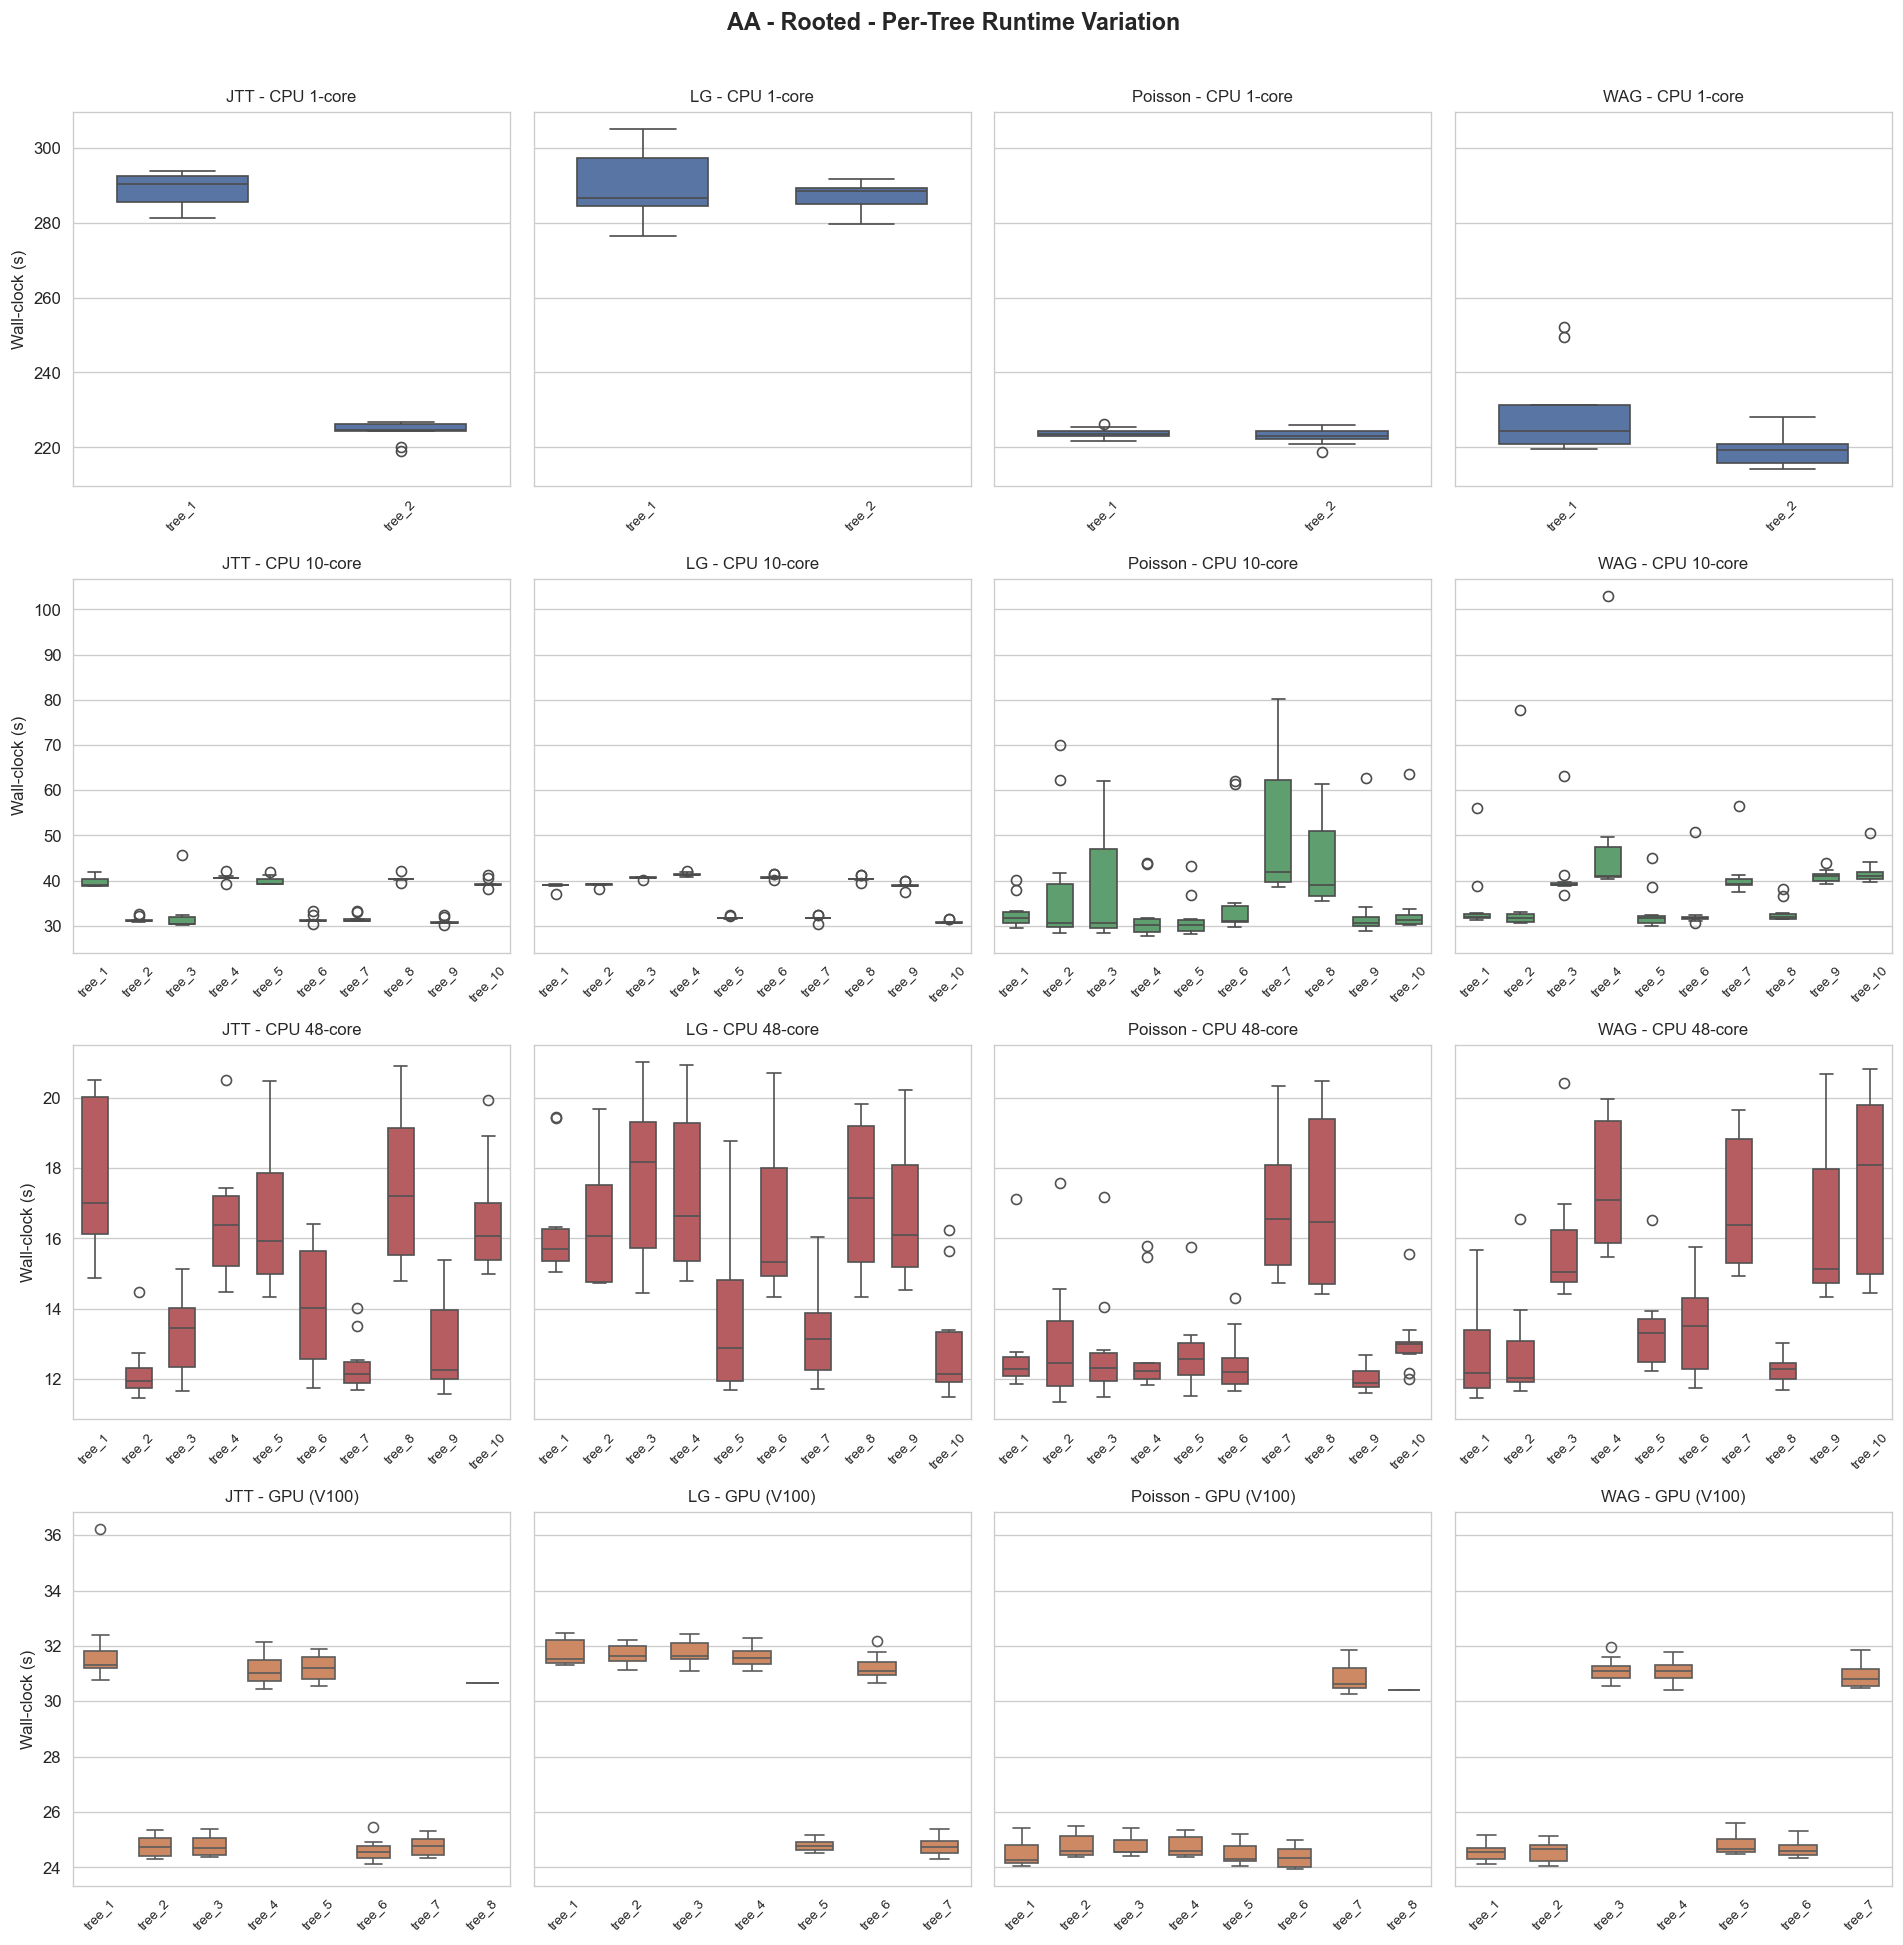

Saved: per_tree_AA_rooted.png


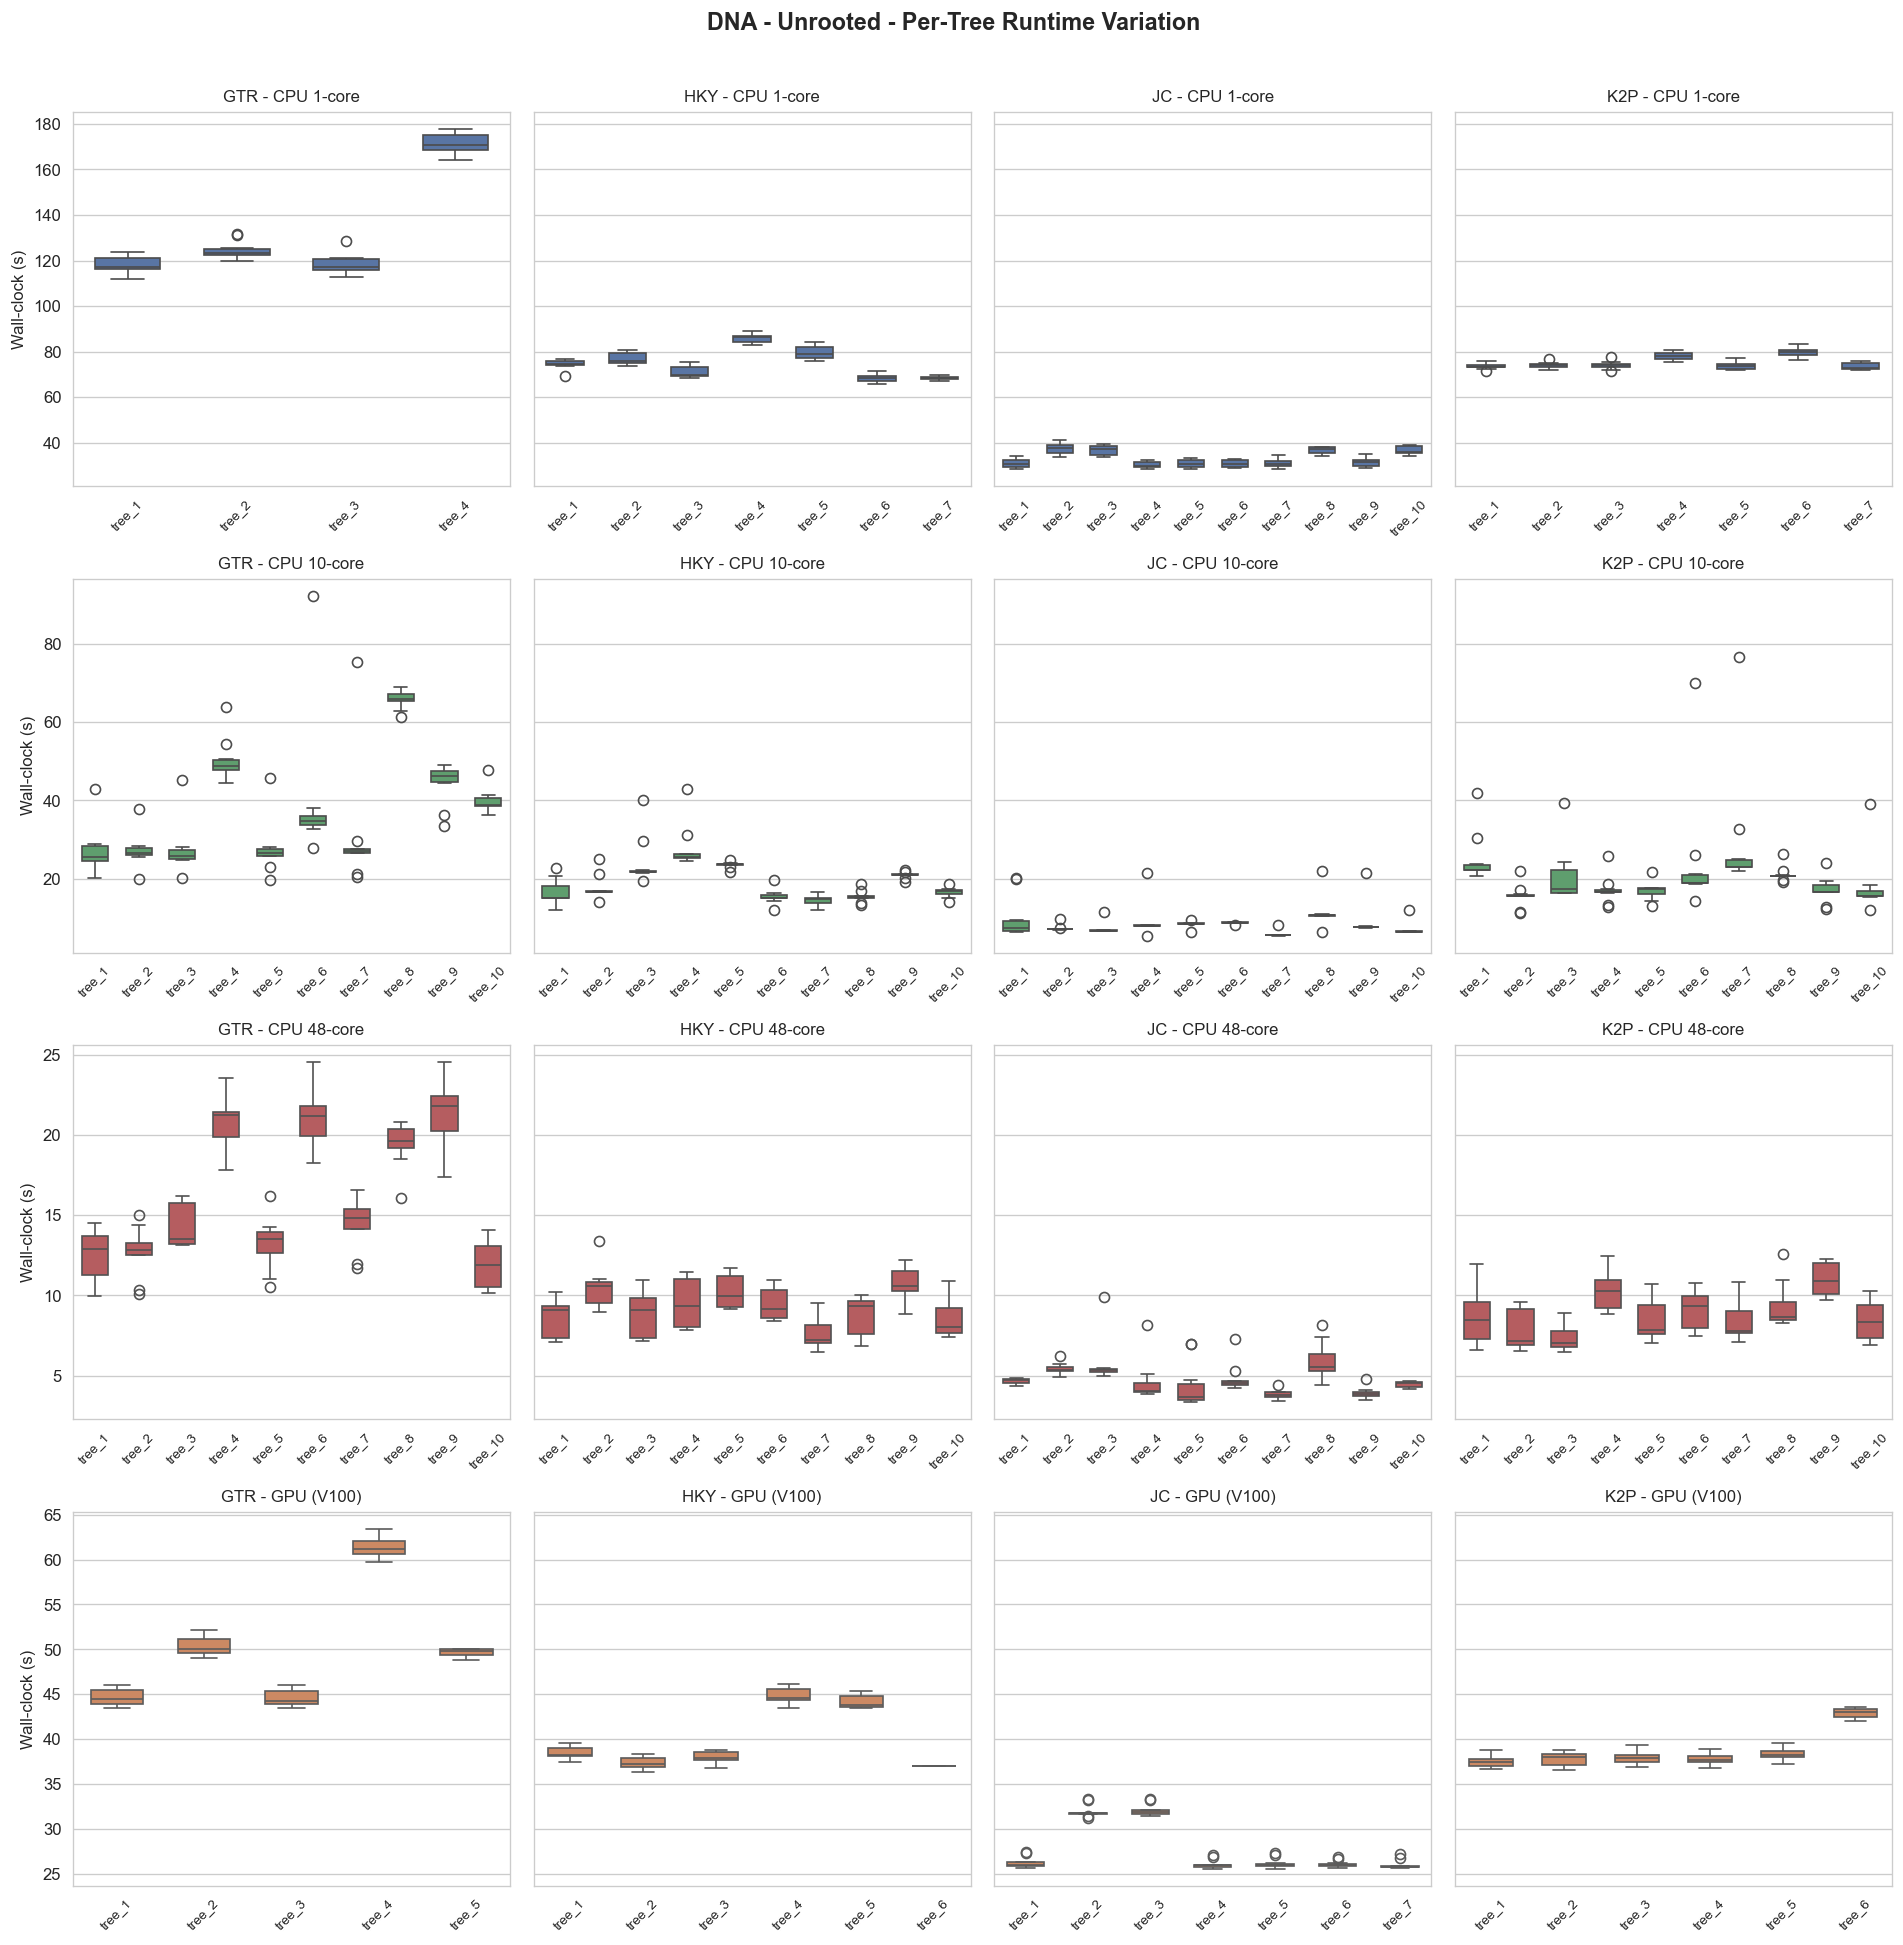

Saved: per_tree_DNA_unrooted.png


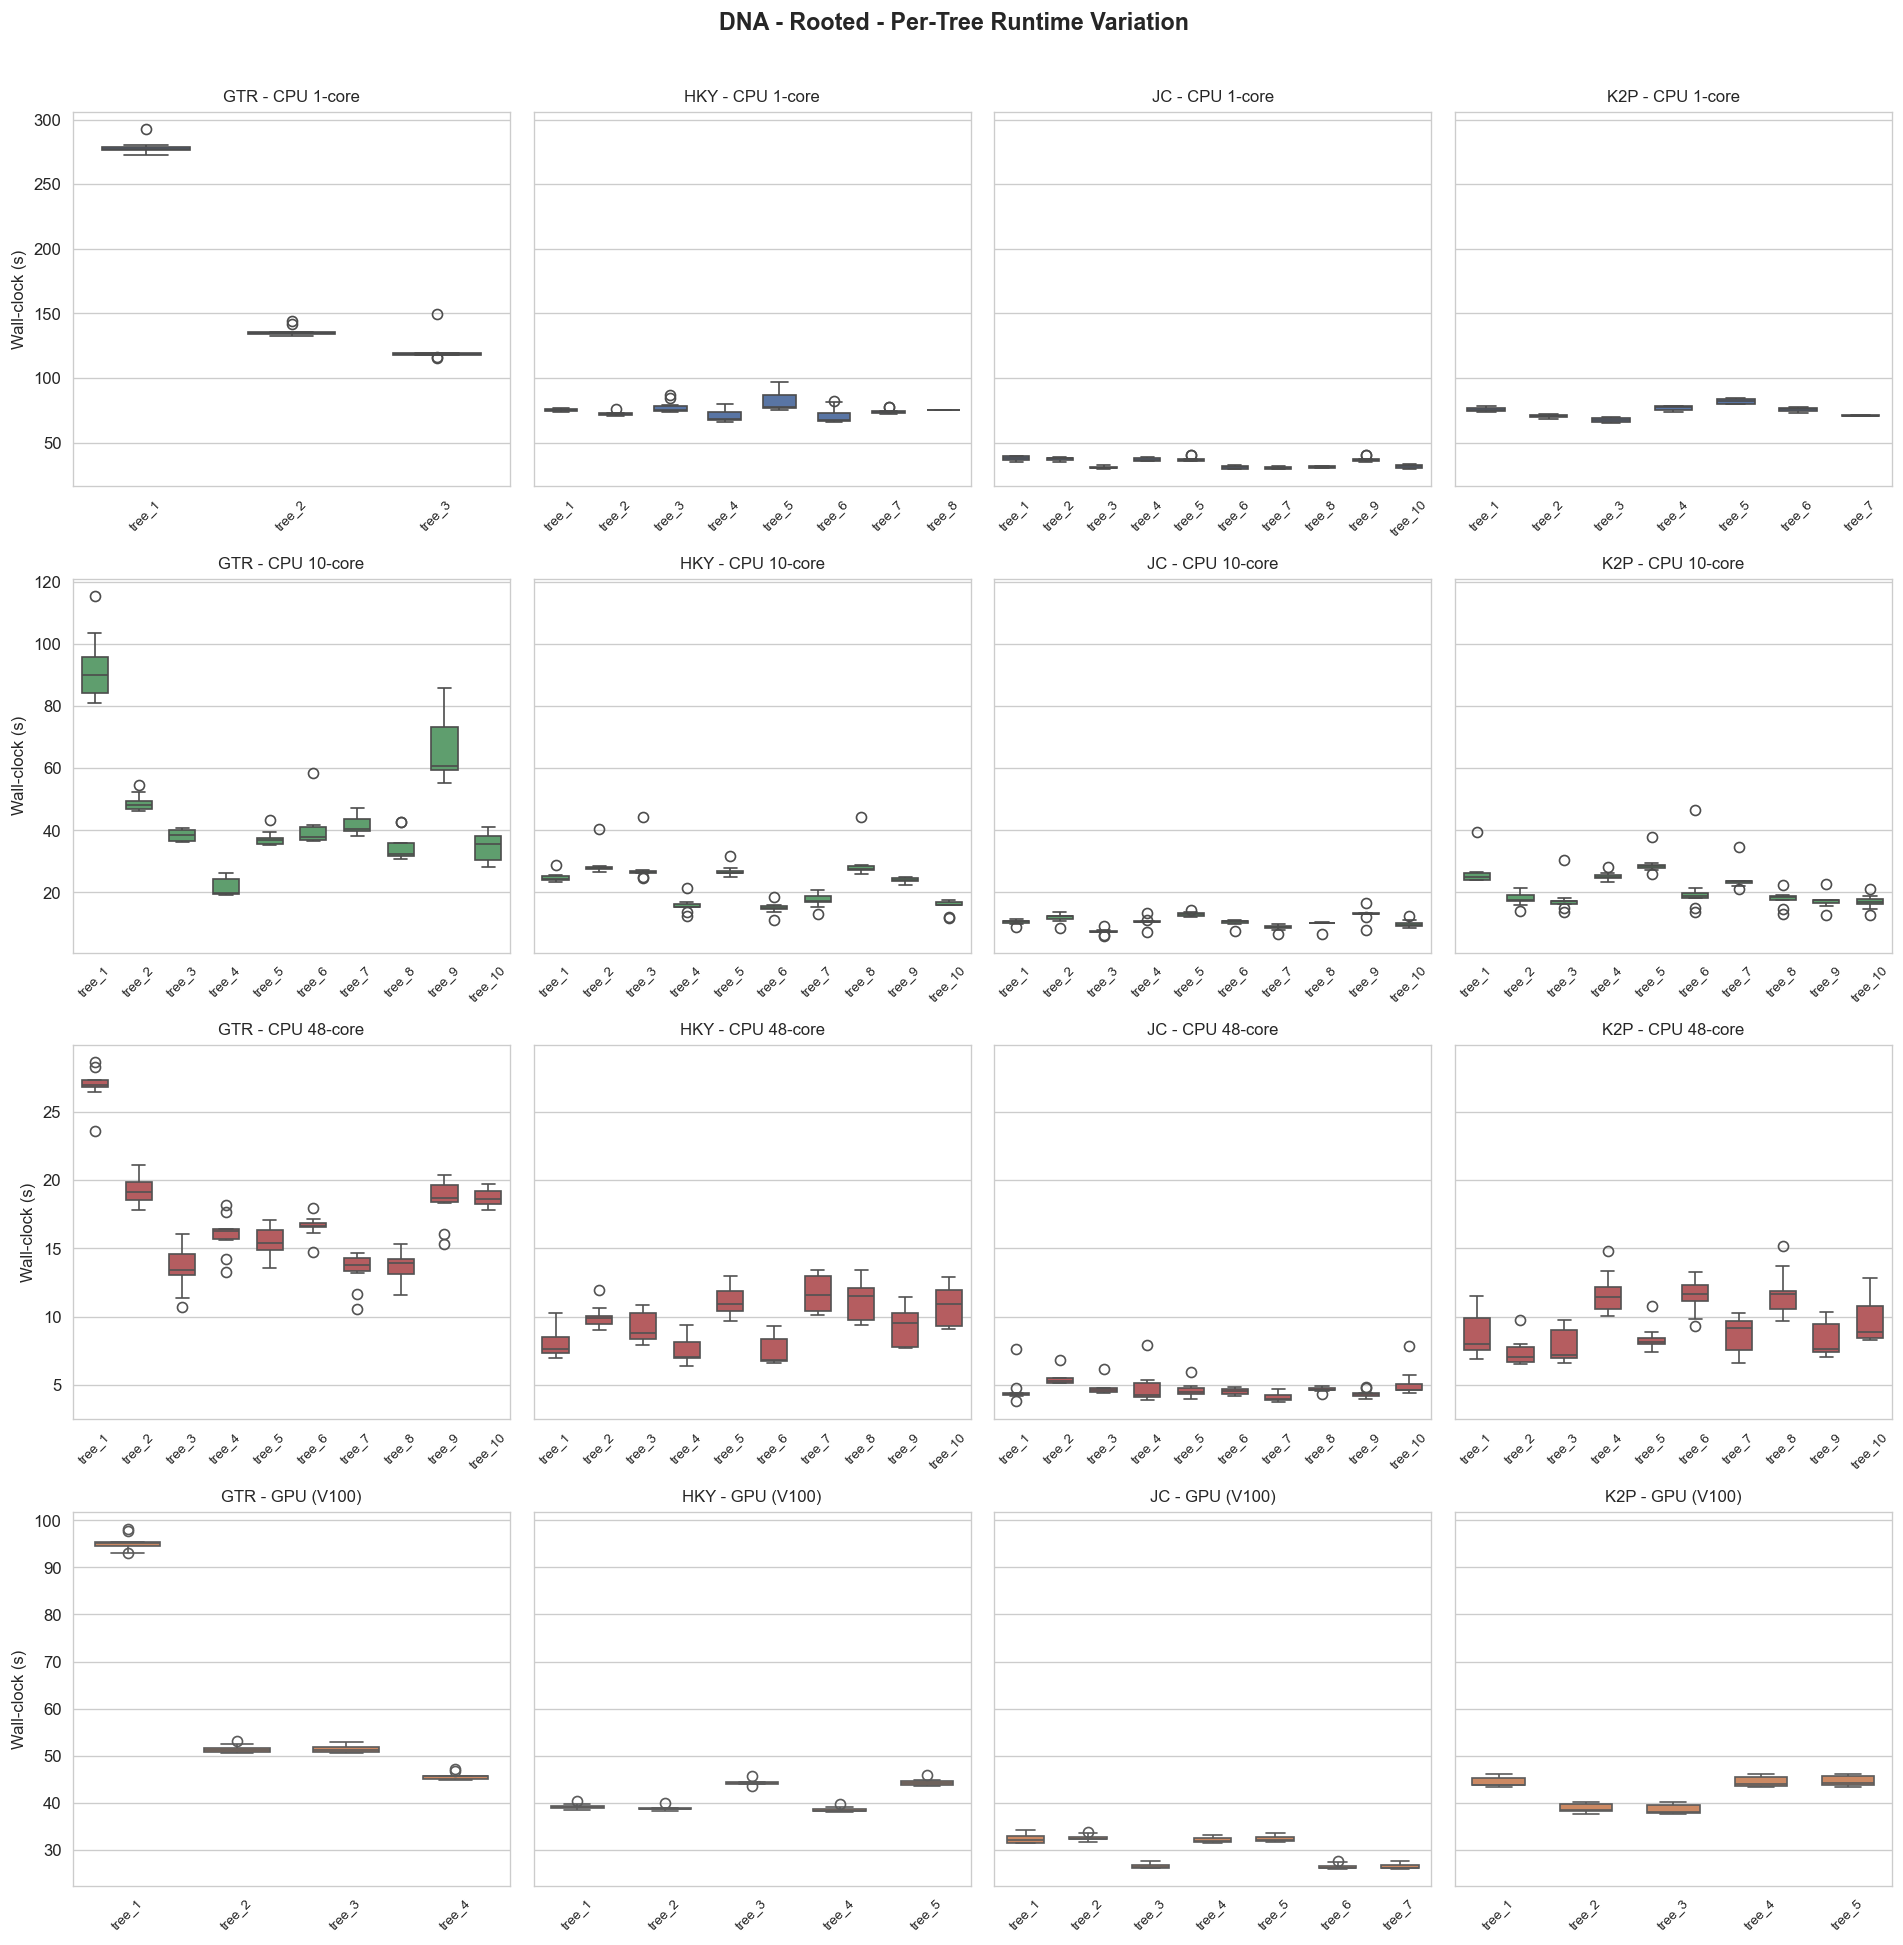

Saved: per_tree_DNA_rooted.png


In [9]:
for data_type in ['AA', 'DNA']:
    for tree_type in ['unrooted', 'rooted']:
        subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)]
        if subset.empty:
            continue
        
        models = sorted(subset['model'].unique())
        present_backends = [b for b in backend_order if b in subset['backend'].unique()]
        
        fig, axes = plt.subplots(len(present_backends), len(models),
                                figsize=(4 * len(models), 4 * len(present_backends)), sharey='row')
        if len(models) == 1:
            axes = axes.reshape(-1, 1)
        if len(present_backends) == 1:
            axes = axes.reshape(1, -1)
        
        for i, backend in enumerate(present_backends):
            for j, model in enumerate(models):
                ax = axes[i][j]
                data = subset[(subset['model'] == model) & (subset['backend'] == backend)]
                if data.empty:
                    ax.set_visible(False)
                    continue
                sns.boxplot(data=data, x='tree', y='walltime',
                           color=backend_colors[backend], ax=ax, width=0.6,
                           order=sorted(data['tree'].unique(), key=lambda x: int(x.split('_')[1])))
                ax.set_title(f'{model} - {backend_labels[backend]}', fontsize=10)
                ax.set_xlabel('')
                ax.set_ylabel('Wall-clock (s)' if j == 0 else '')
                ax.tick_params(axis='x', rotation=45, labelsize=8)
        
        fig.suptitle(f'{data_type} - {tree_type.capitalize()} - Per-Tree Runtime Variation',
                    fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        fname = f'per_tree_{data_type}_{tree_type}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## 8. Optimization Time Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

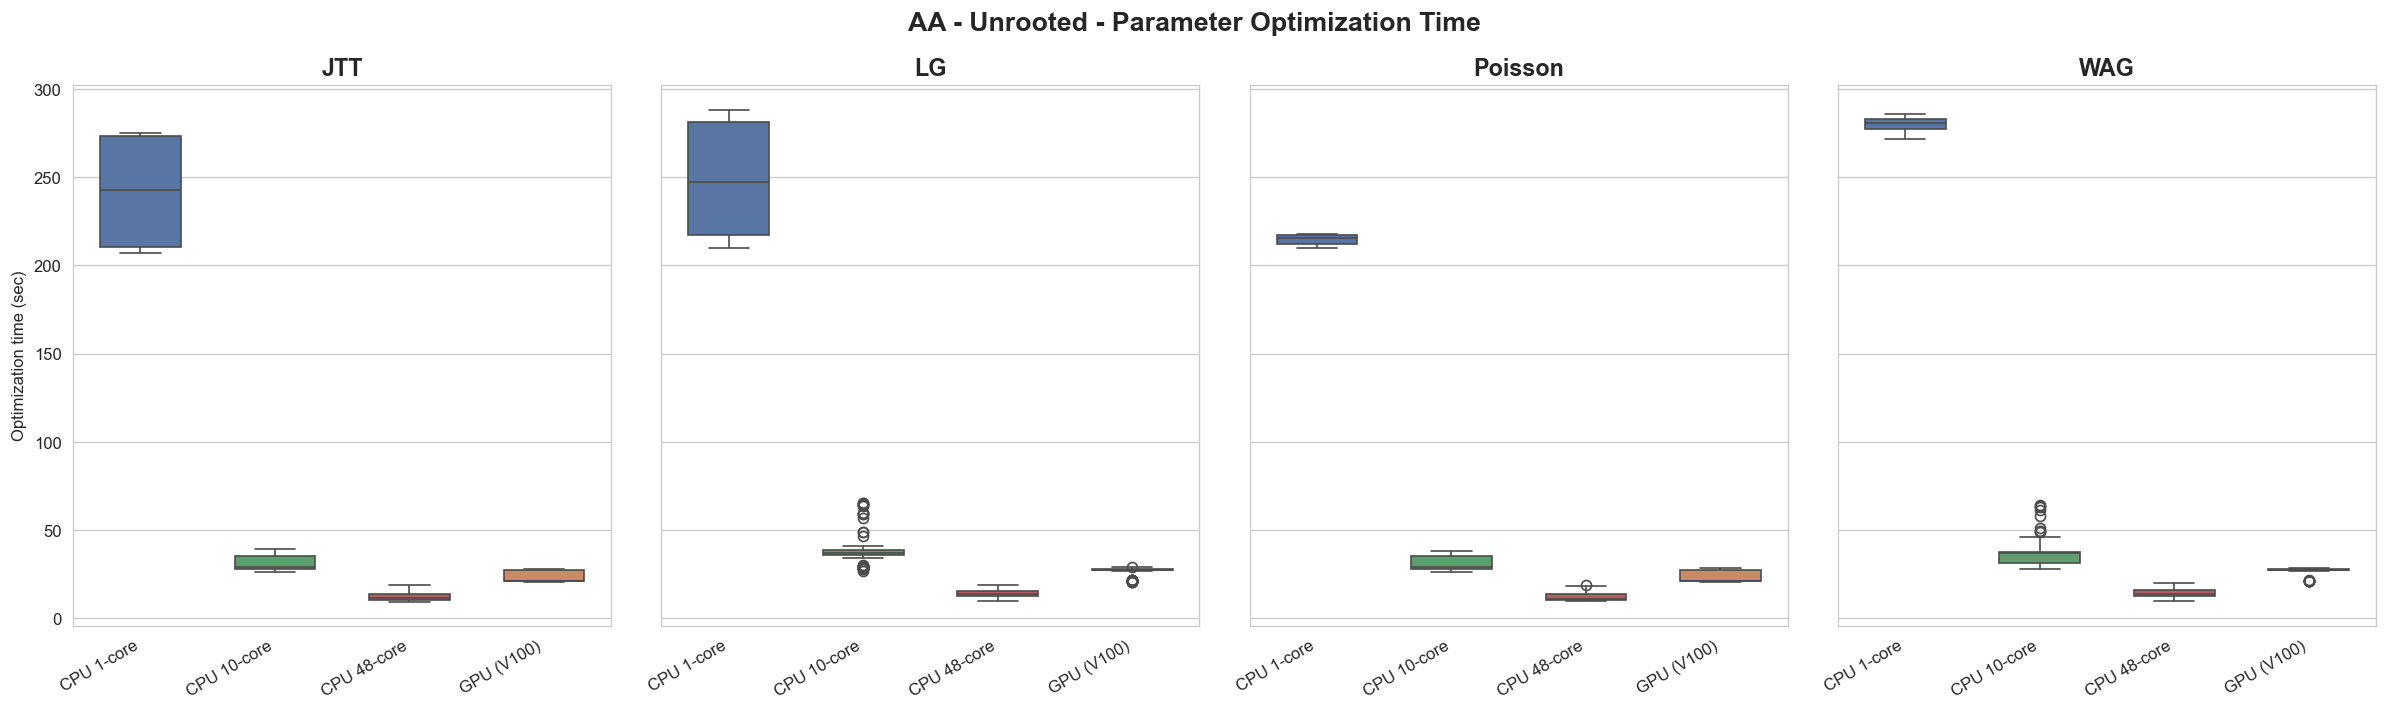

Saved: opt_time_AA_unrooted.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

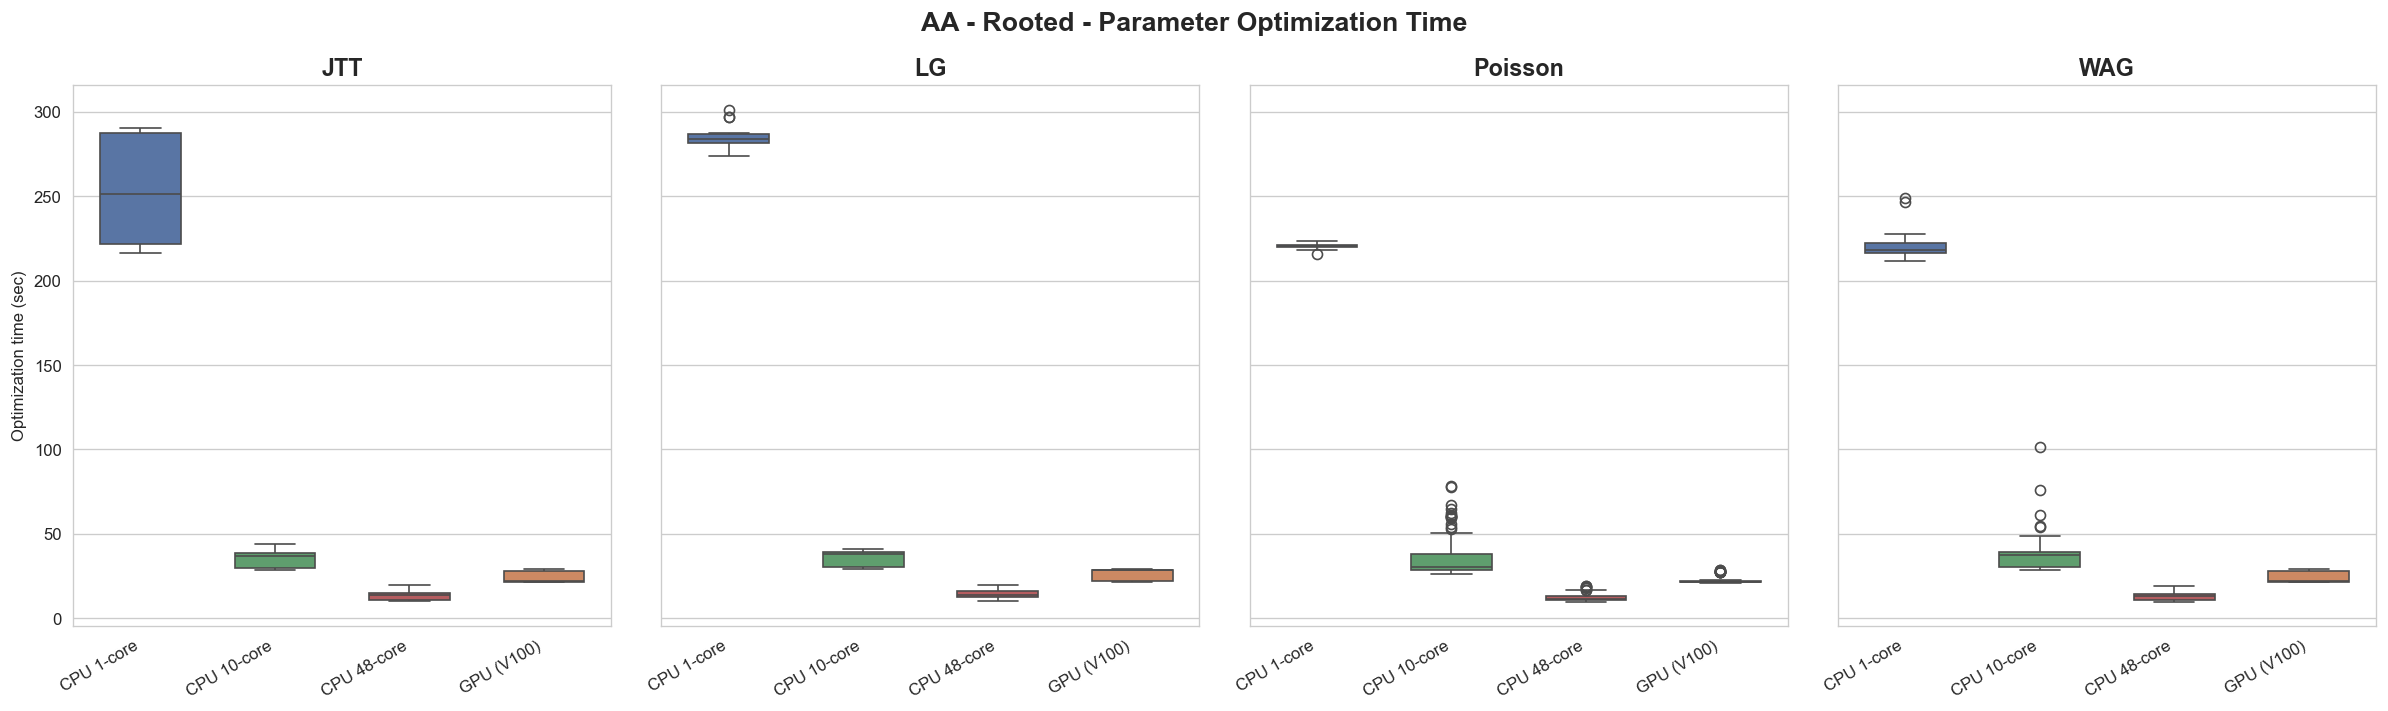

Saved: opt_time_AA_rooted.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

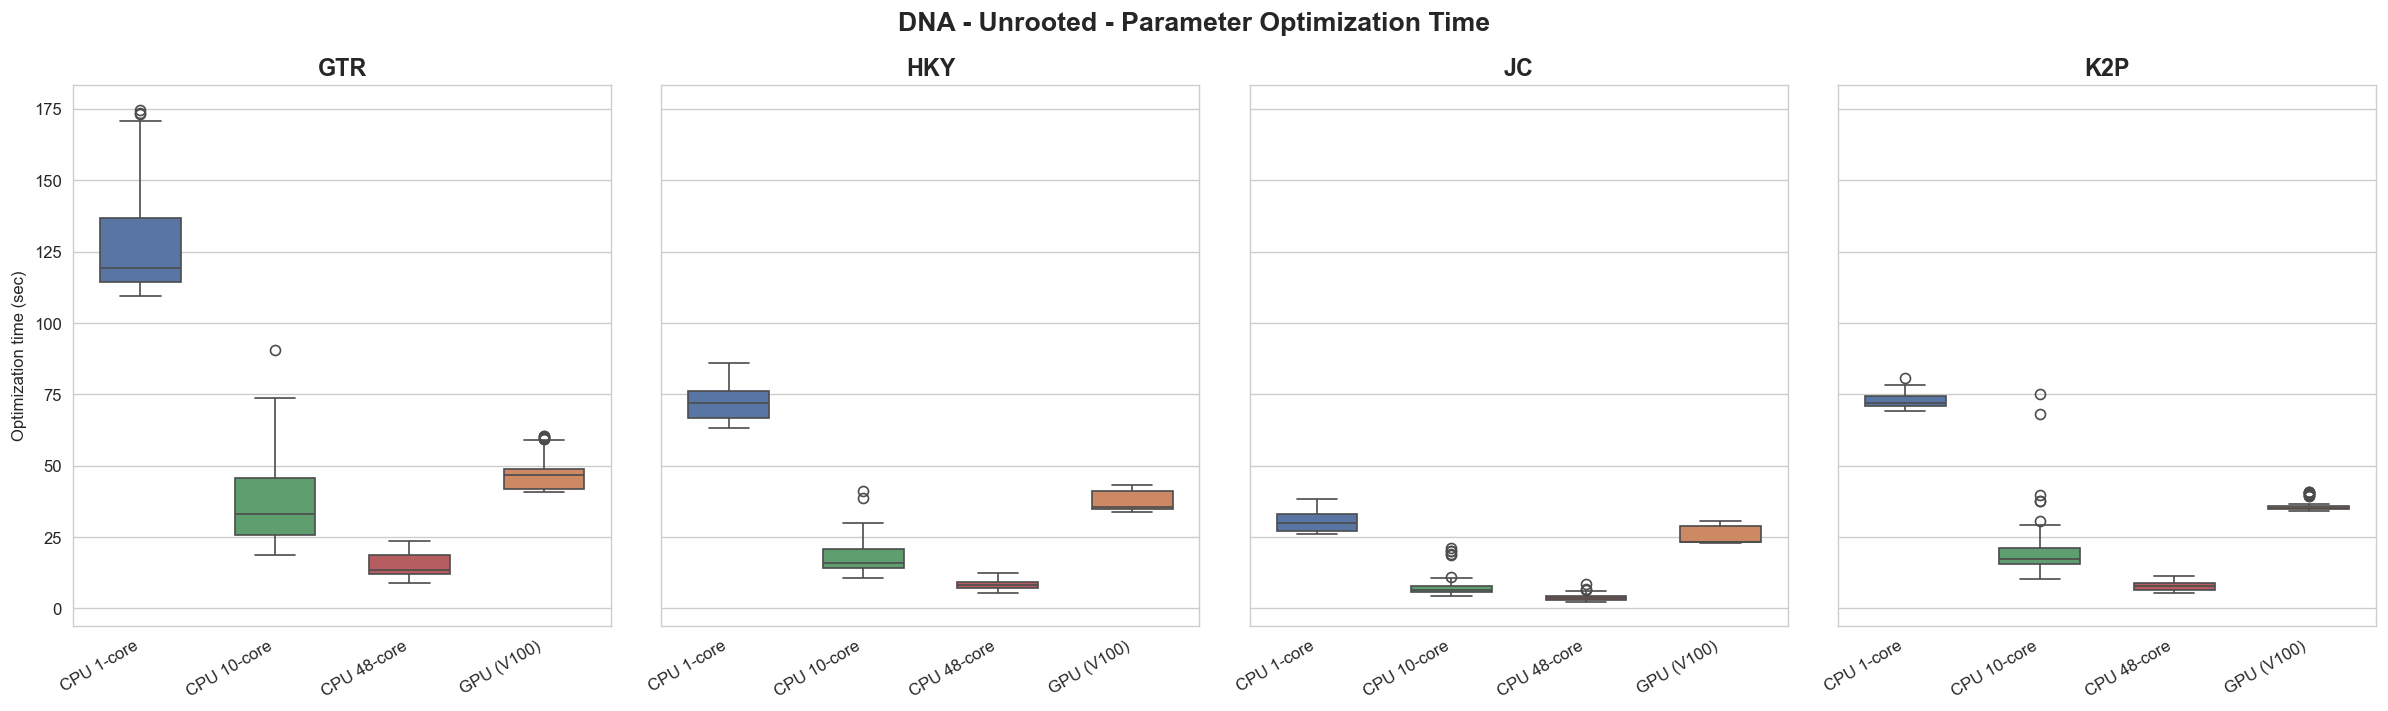

Saved: opt_time_DNA_unrooted.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_55217/1643951482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_data, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_

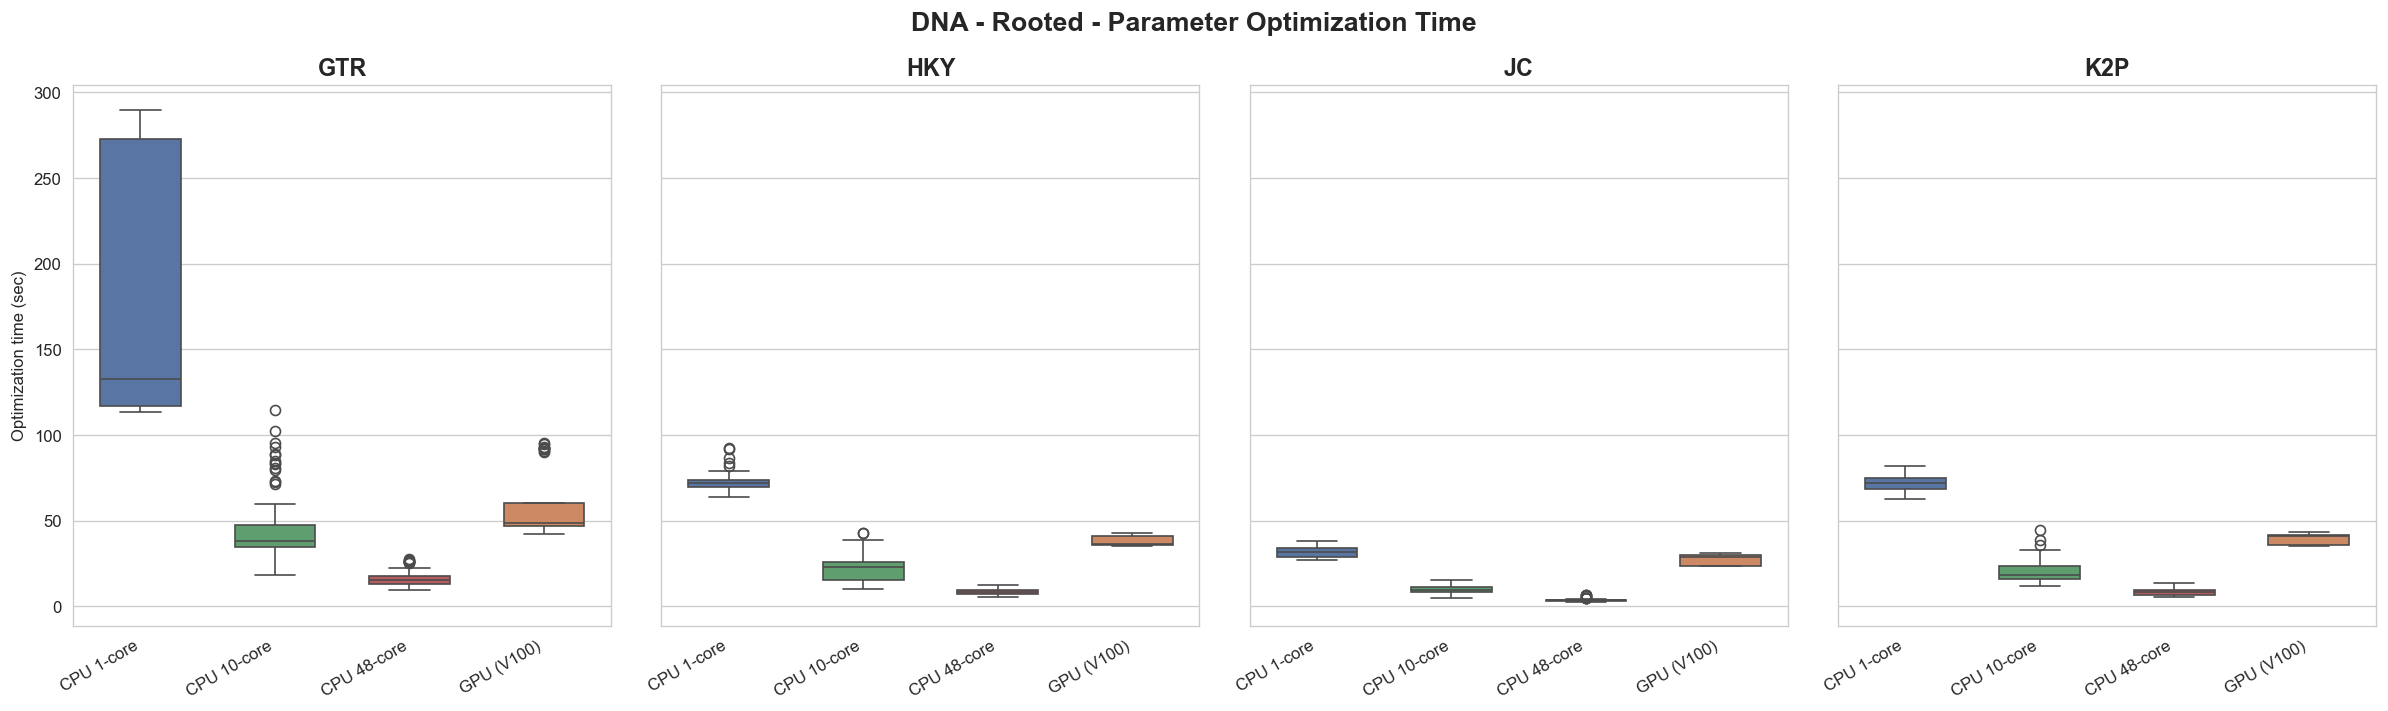

Saved: opt_time_DNA_rooted.png


In [10]:
for data_type in ['AA', 'DNA']:
    for tree_type in ['unrooted', 'rooted']:
        subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)].dropna(subset=['opt_time'])
        if subset.empty:
            continue
        
        models = sorted(subset['model'].unique())
        fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 6), sharey=True)
        if len(models) == 1:
            axes = [axes]
        
        for ax, model in zip(axes, models):
            model_data = subset[subset['model'] == model]
            present_backends = [b for b in backend_order if b in model_data['backend'].unique()]
            palette = [backend_colors[b] for b in present_backends]
            
            sns.boxplot(data=model_data, x='backend', y='opt_time',
                       order=present_backends, palette=palette, ax=ax, width=0.6)
            ax.set_title(model, fontsize=14, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel('Optimization time (sec)' if ax == axes[0] else '')
            ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], rotation=30, ha='right')
        
        fig.suptitle(f'{data_type} - {tree_type.capitalize()} - Parameter Optimization Time',
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        fname = f'opt_time_{data_type}_{tree_type}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## 9. Speedup Heatmaps (per model x tree)

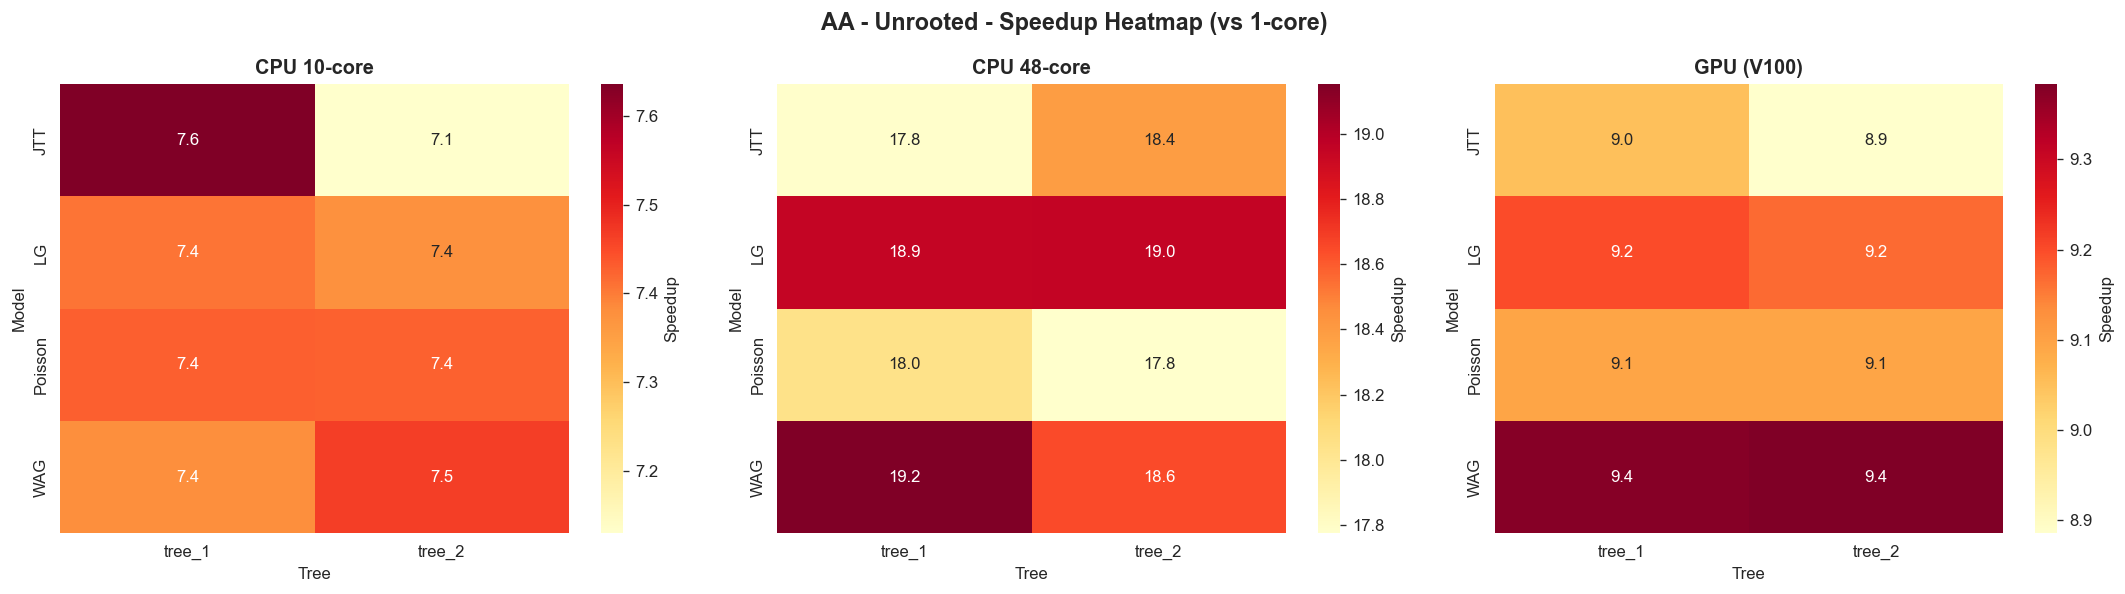

Saved: heatmap_AA_unrooted.png


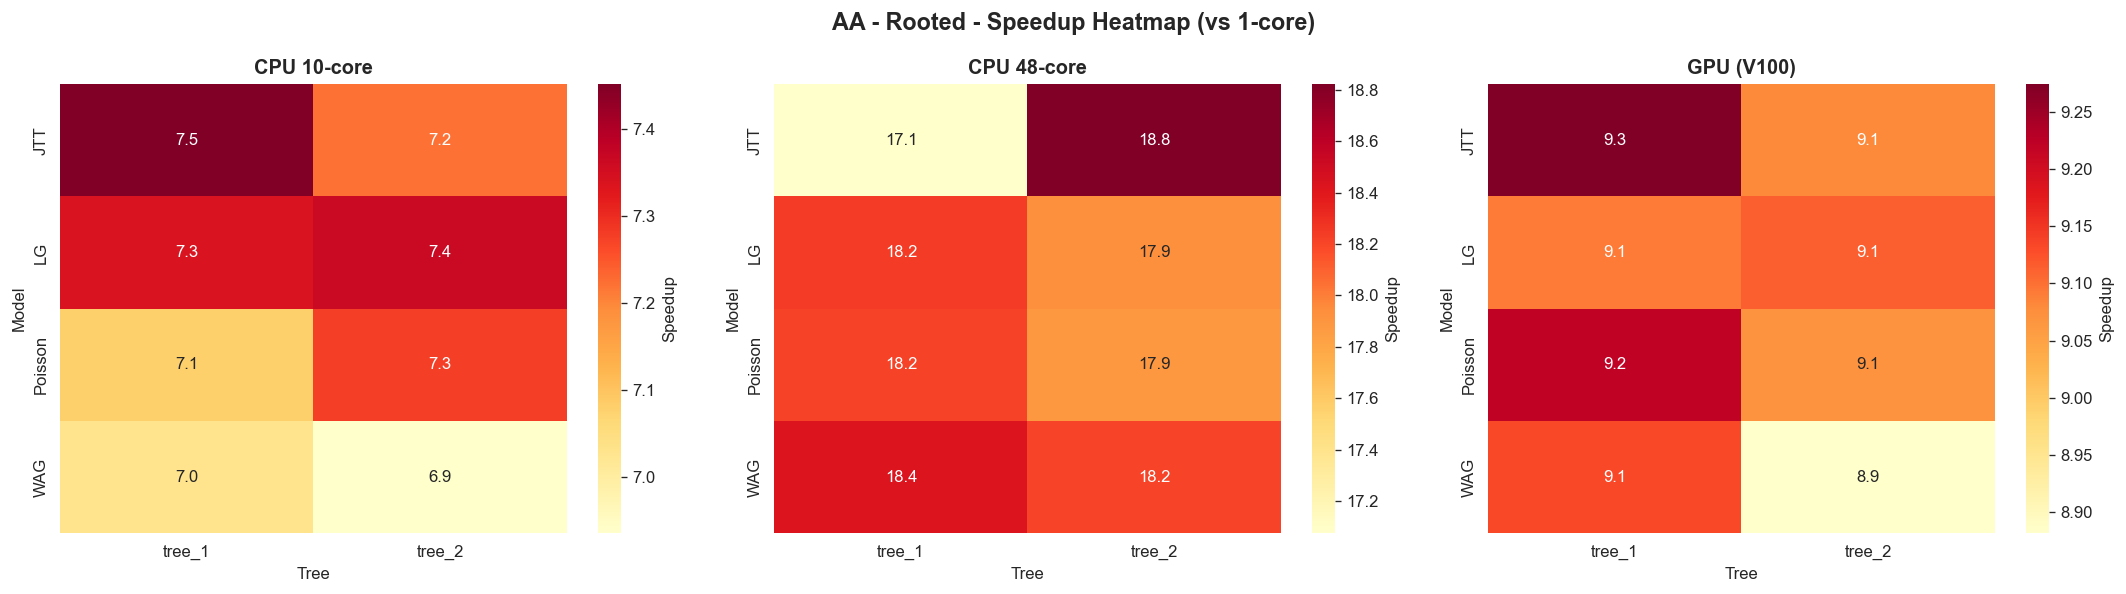

Saved: heatmap_AA_rooted.png


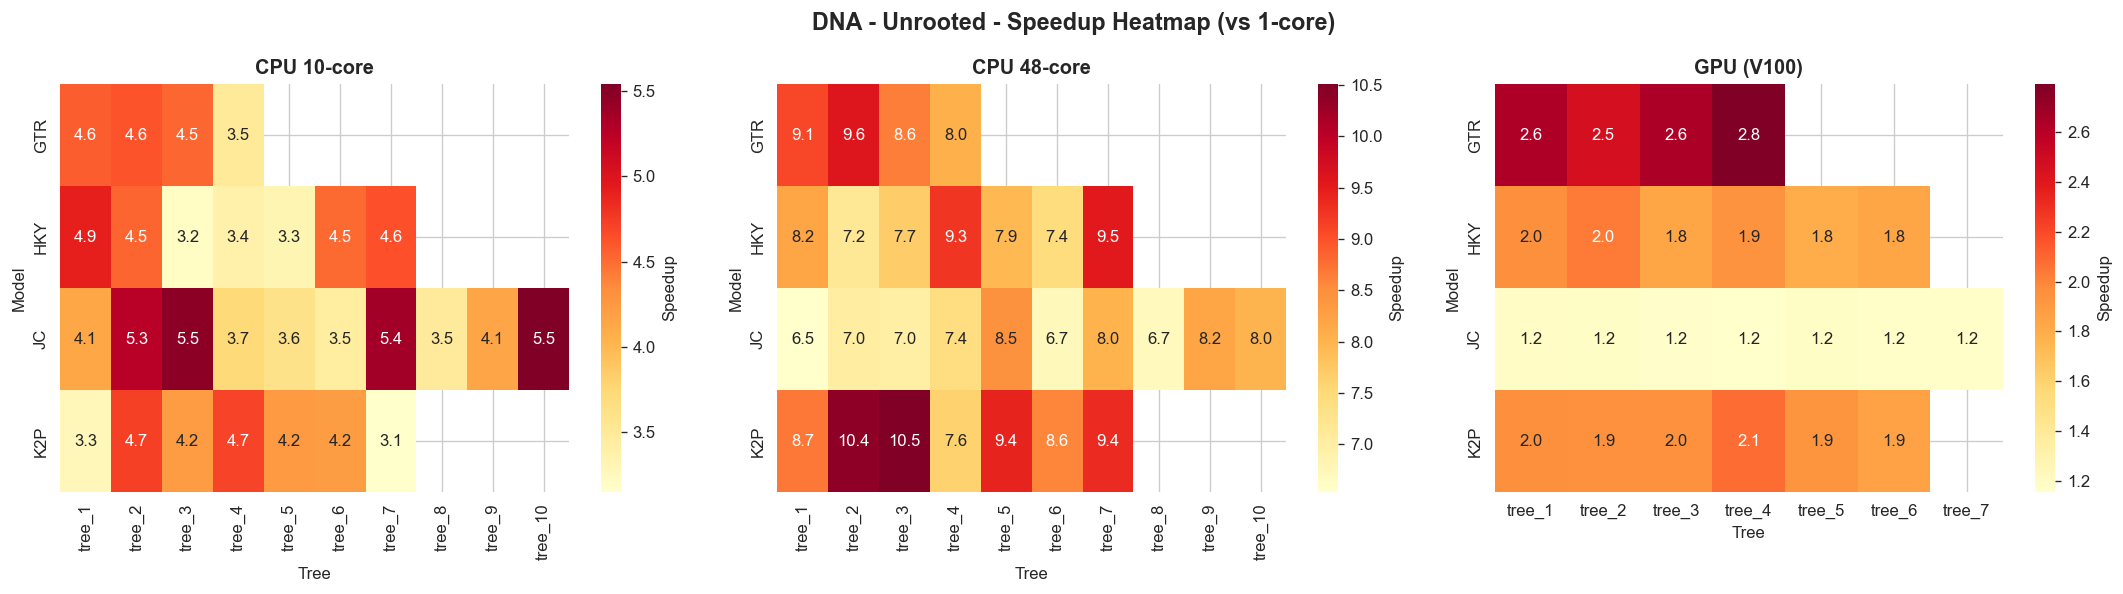

Saved: heatmap_DNA_unrooted.png


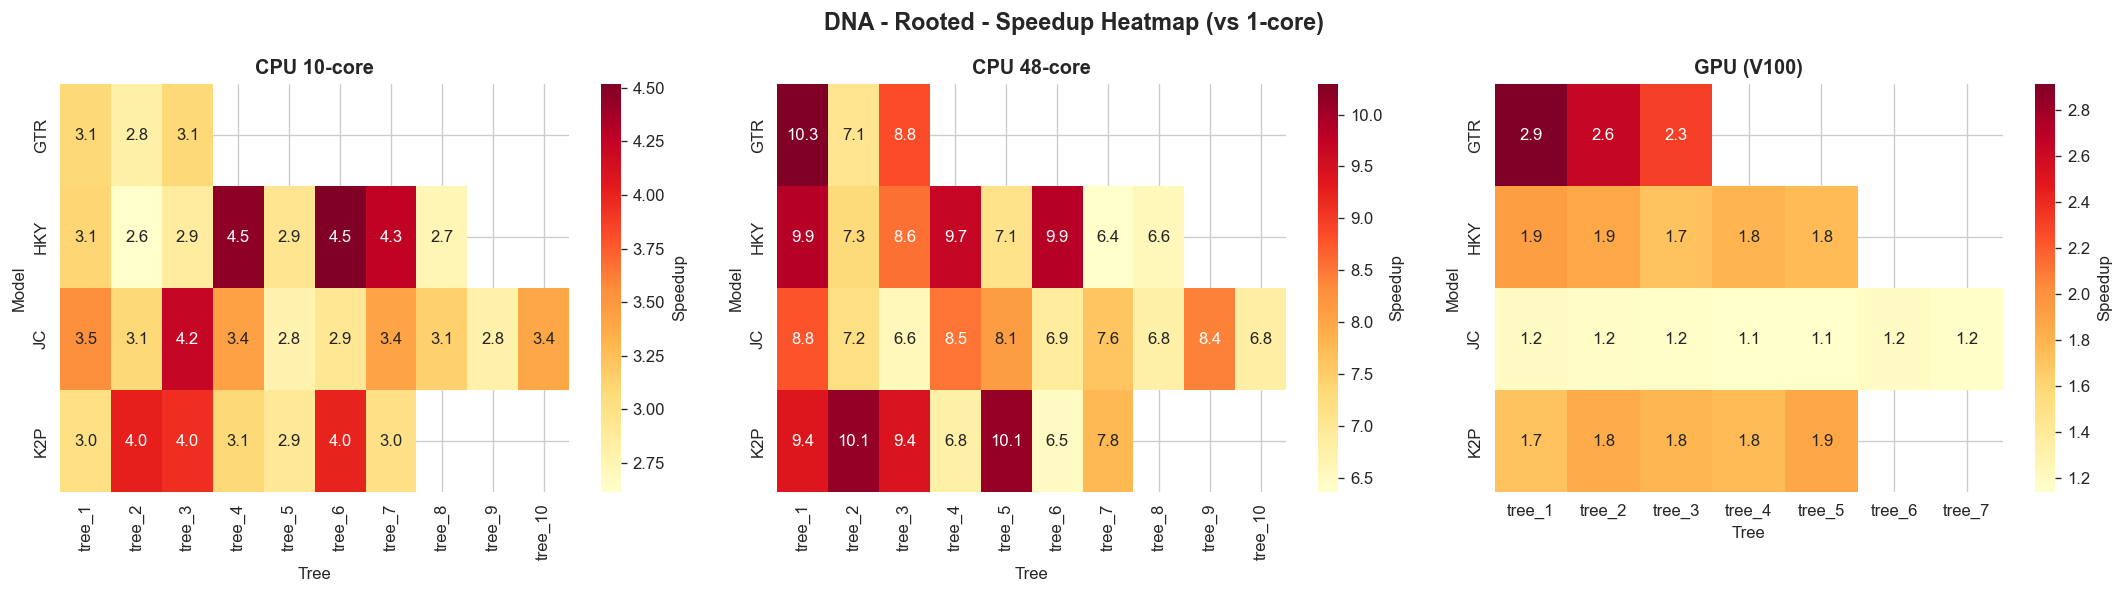

Saved: heatmap_DNA_rooted.png


In [11]:
for data_type in ['AA', 'DNA']:
    for tree_type in ['unrooted', 'rooted']:
        sub = pivot[(pivot['data_type'] == data_type) & (pivot['tree_type'] == tree_type)]
        if sub.empty:
            continue
        
        present_speedups = [c for c in speedup_cols if c in sub.columns and sub[c].notna().any()]
        if not present_speedups:
            continue
        
        fig, axes = plt.subplots(1, len(present_speedups),
                                figsize=(6 * len(present_speedups), 5))
        if len(present_speedups) == 1:
            axes = [axes]
        
        for ax, col in zip(axes, present_speedups):
            hm_data = sub.pivot_table(index='model', columns='tree', values=col, aggfunc='mean')
            # Sort tree columns numerically
            hm_data = hm_data[sorted(hm_data.columns, key=lambda x: int(x.split('_')[1]))]
            sns.heatmap(hm_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                       cbar_kws={'label': 'Speedup'})
            ax.set_title(f'{speedup_labels.get(col, col)}', fontsize=12, fontweight='bold')
            ax.set_ylabel('Model')
            ax.set_xlabel('Tree')
        
        fig.suptitle(f'{data_type} - {tree_type.capitalize()} - Speedup Heatmap (vs 1-core)',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        fname = f'heatmap_{data_type}_{tree_type}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## 10. Combined Overview: All Backends, All Models

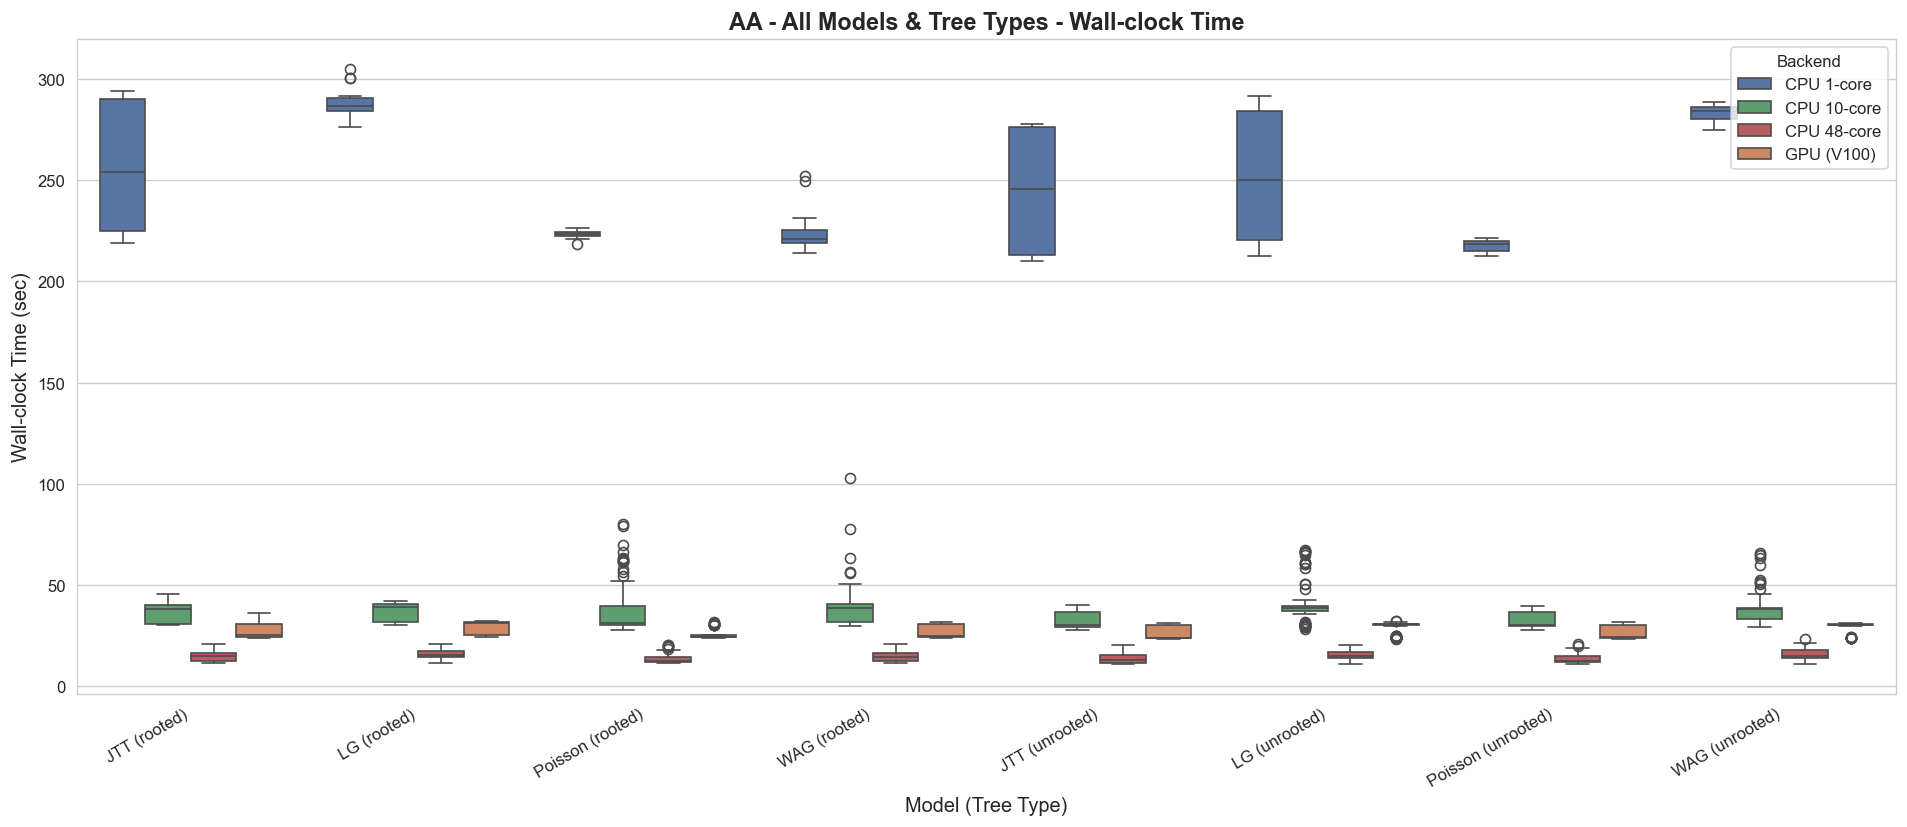

Saved: overview_AA.png


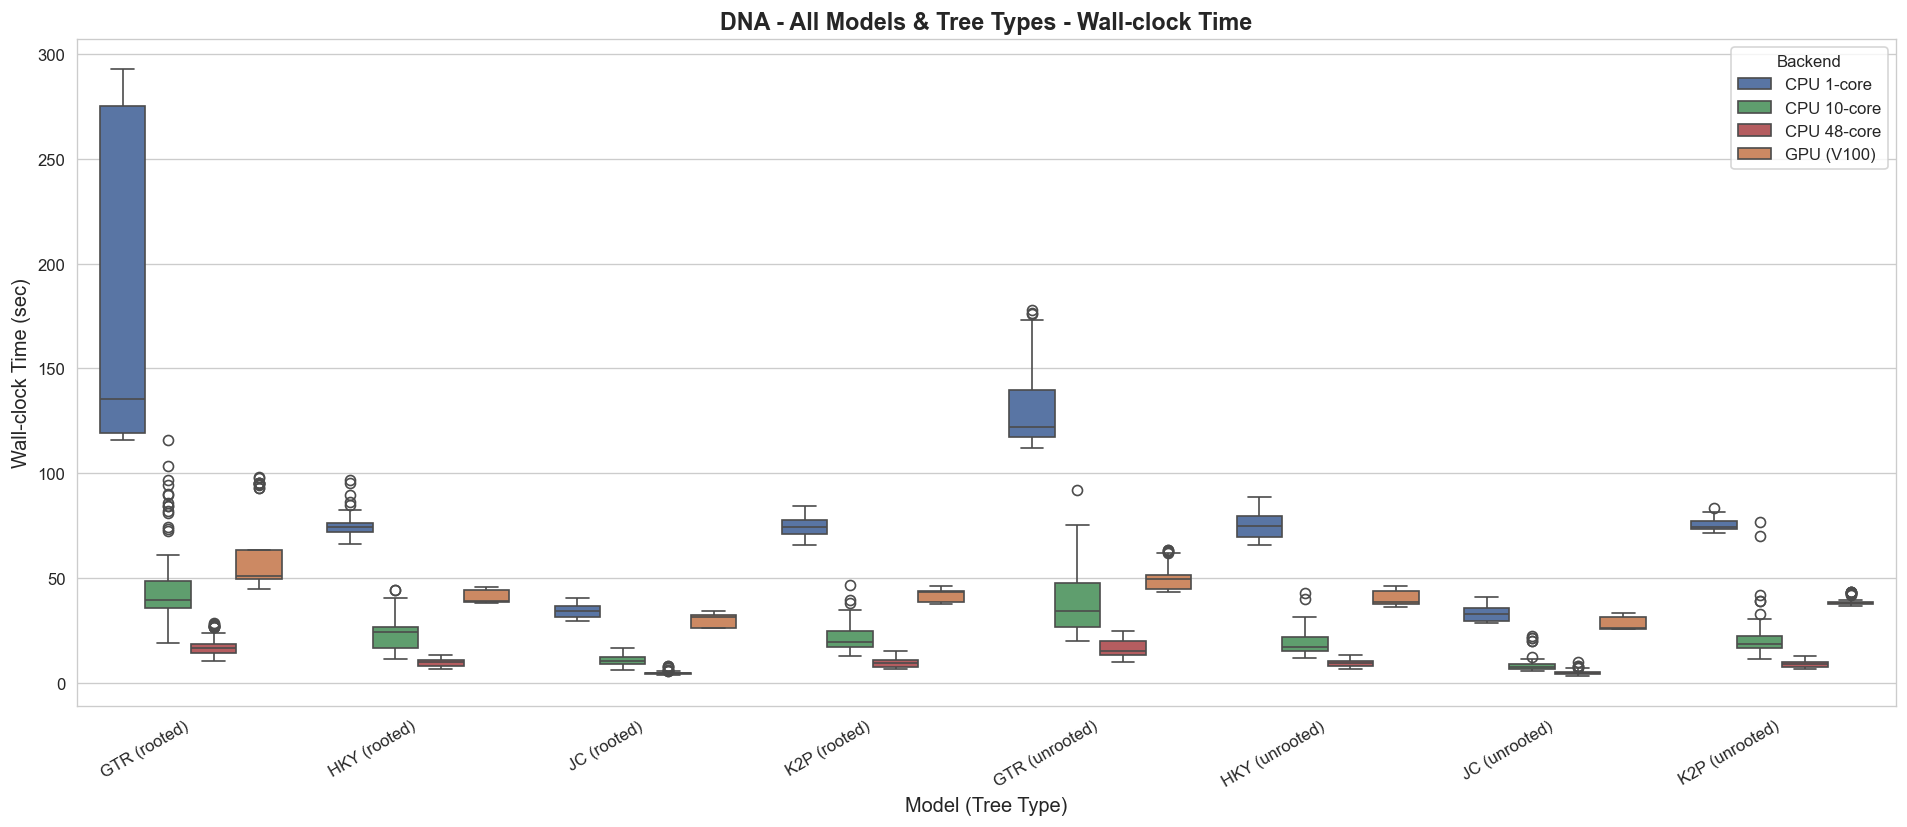

Saved: overview_DNA.png


In [12]:
for data_type in ['AA', 'DNA']:
    subset = df[df['data_type'] == data_type].copy()
    if subset.empty:
        continue
    
    subset['config'] = subset['model'] + ' (' + subset['tree_type'] + ')'
    present_backends = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present_backends]
    
    fig, ax = plt.subplots(figsize=(16, 7))
    sns.boxplot(data=subset, x='config', y='walltime', hue='backend',
               hue_order=present_backends, palette=palette, ax=ax)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [backend_labels.get(l, l) for l in labels],
             title='Backend', fontsize=10, loc='upper right')
    ax.set_xlabel('Model (Tree Type)', fontsize=12)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_title(f'{data_type} - All Models & Tree Types - Wall-clock Time',
                fontsize=14, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    fname = f'overview_{data_type}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 11. Rooted vs Unrooted Comparison

In [13]:
# Compare median walltime between rooted and unrooted for each backend/model
rooted_vs_unrooted = df.groupby(['data_type', 'tree_type', 'model', 'backend'])['walltime'].median().reset_index()
rooted_vs_unrooted = rooted_vs_unrooted.pivot_table(index=['data_type', 'model', 'backend'],
                                                     columns='tree_type',
                                                     values='walltime').reset_index()
if 'rooted' in rooted_vs_unrooted.columns and 'unrooted' in rooted_vs_unrooted.columns:
    rooted_vs_unrooted['rooted_overhead'] = (
        (rooted_vs_unrooted['rooted'] - rooted_vs_unrooted['unrooted']) /
        rooted_vs_unrooted['unrooted'] * 100
    ).round(2)
    
    print('Rooted vs Unrooted: % overhead of rooted trees')
    display(rooted_vs_unrooted.sort_values(['data_type', 'model', 'backend']))
    rooted_vs_unrooted.to_csv(SAVE_DIR / 'rooted_vs_unrooted.csv', index=False)
else:
    print('Both rooted and unrooted data needed for comparison.')

Rooted vs Unrooted: % overhead of rooted trees


tree_type,data_type,model,backend,rooted,unrooted,rooted_overhead
0,AA,JTT,OMP_10,38.4410,30.2620,27.03
1,AA,JTT,OMP_48,14.9135,13.0870,13.96
2,AA,JTT,OPENACC,25.2600,24.1150,4.75
3,AA,JTT,VANILA,253.9795,245.6215,3.40
4,AA,LG,OMP_10,39.1365,38.5585,1.50
5,AA,LG,OMP_48,15.4245,15.0195,2.70
6,AA,LG,OPENACC,31.3740,30.5990,2.53
7,AA,LG,VANILA,286.5870,250.2900,14.50
8,AA,Poisson,OMP_10,31.5030,30.3850,3.68
9,AA,Poisson,OMP_48,12.6035,12.5285,0.60


## 12. Summary Table: Mean Wall-clock Time (sec)

In [14]:
# Final clean summary table
final_summary = df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    mean_walltime=('walltime', 'mean'),
    median_walltime=('walltime', 'median'),
    std_walltime=('walltime', 'std'),
    mean_opt_time=('opt_time', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

# Add speedup column (vs VANILA)
vanila_times = final_summary[final_summary['backend'] == 'VANILA'][['data_type', 'tree_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'vanila_median'})
final_summary = final_summary.merge(vanila_times, on=['data_type', 'tree_type', 'model'], how='left')
final_summary['speedup'] = (final_summary['vanila_median'] / final_summary['median_walltime']).round(2)
final_summary = final_summary.drop(columns=['vanila_median'])

final_summary.to_csv(SAVE_DIR / 'final_summary.csv', index=False)

# Display as styled table
display(final_summary.style.format({'speedup': '{:.2f}x'}).background_gradient(
    subset=['speedup'], cmap='Greens'))

,data_type,tree_type,model,backend,mean_walltime,median_walltime,std_walltime,mean_opt_time,n_runs,speedup
0,AA,rooted,JTT,OMP_10,35.720000,38.440000,4.580000,34.420000,100,6.61x
1,AA,rooted,JTT,OMP_48,14.990000,14.910000,2.630000,13.560000,100,17.03x
2,AA,rooted,JTT,OPENACC,27.630000,25.260000,3.400000,24.650000,71,10.05x
3,AA,rooted,JTT,VANILA,256.580000,253.980000,33.380000,253.530000,20,1.00x
4,AA,rooted,LG,OMP_10,37.420000,39.140000,4.050000,36.140000,100,7.32x
5,AA,rooted,LG,OMP_48,15.810000,15.420000,2.600000,14.360000,100,18.59x
6,AA,rooted,LG,OPENACC,29.660000,31.370000,3.130000,26.720000,70,9.14x
7,AA,rooted,LG,VANILA,288.200000,286.590000,7.690000,285.030000,17,1.00x
8,AA,rooted,Poisson,OMP_10,37.460000,31.500000,12.160000,36.000000,100,7.09x
9,AA,rooted,Poisson,OMP_48,13.580000,12.600000,2.270000,12.230000,100,17.73x
